# Project 7: English-Italian Neural Machine Translation

This project implements a complete neural machine translation (NMT) pipeline for English to Italian translation, comparing two state-of-the-art architectures:

1. **LSTM Seq2Seq with Attention**: A recurrent neural network approach with Bahdanau attention mechanism
2. **Transformer**: An attention-based architecture from the "Attention is All You Need" paper

## Project Overview

Machine translation remains one of the most important applications of NLP, with modern neural approaches significantly outperforming traditional statistical methods. This project explores the strengths and limitations of two leading NMT architectures, providing insights into their performance characteristics and design tradeoffs.

## Key Components

- **Data**: Helsinki-NLP/opus-100 English-Italian parallel corpus
- **Preprocessing**: Analysis, cleaning, and BPE tokenization
- **Models**: LSTM with attention and Transformer implementations
- **Training**: Optimized training with early stopping and learning rate scheduling
- **Evaluation**: BLEU and SacreBLEU metrics
- **Analysis**: Error analysis and translation quality assessment

## Results Preview

Our experiments show that the Transformer architecture achieves superior performance compared to the LSTM approach, with significant improvements in both BLEU and SacreBLEU scores. The notebook presents a comprehensive analysis of each model's strengths and weaknesses, along with example translations to illustrate the qualitative differences.

*Author: Nixon Ng*  
*Date: 6th May 2025*

In [1]:
!pip install torch torchtext nltk sacrebleu sentencepiece matplotlib seaborn pandas tqdm datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# (If using Google Colab)
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

### Define the Directory in Google Drive ###
DRIVE_SAVE_DIR = '/content/drive/MyDrive/NLP_Pipeline_Outputs'

# Create the directory if it doesn't exist
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"All outputs will be saved to: {DRIVE_SAVE_DIR}")

### Change the Current Working Directory ###
os.chdir(DRIVE_SAVE_DIR)
print(f"Current working directory changed to: {os.getcwd()}")

Mounted at /content/drive
All outputs will be saved to: /content/drive/MyDrive/NLP_Pipeline_Outputs
Current working directory changed to: /content/drive/MyDrive/NLP_Pipeline_Outputs


In [4]:
print("\n--- Files in Save Directory ---")
print(os.listdir(DRIVE_SAVE_DIR))


--- Files in Save Directory ---
['best_lite_lstm_model_bpe_vocab16000.pt', 'best_lite_transformer_model_bpe_vocab16000.pt', 'en_tokenizer_bpe_v16000.model', 'en_tokenizer_bpe_v16000.vocab', 'it_tokenizer_bpe_v16000.model', 'it_tokenizer_bpe_v16000.vocab', 'en_tokenizer_bpe.model', 'en_tokenizer_bpe_train_data.txt', 'en_tokenizer_bpe.vocab', 'it_tokenizer_bpe_train_data.txt', 'it_tokenizer_bpe.model', 'it_tokenizer_bpe.vocab']


## 1. Imports and Setup Section

In [ ]:
# --- Imports and Configuration ---
"""
This project implements an English-Italian Neural Machine Translation system using both
LSTM and Transformer architectures. It handles the complete pipeline from data loading, 
preprocessing, model training, to evaluation.

Key components:
- Dataset: Helsinki-NLP/opus-100 (English-Italian parallel corpus)
- Tokenization: BPE using SentencePiece (vocab size 16k)
- Models: LSTM with Attention and Transformer
- Evaluation: BLEU and SacreBLEU

Author: Nixon Ng
Date: 6th May 2025
"""

# --- Standard library imports ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import logging
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import random
import math
import time
import re
import os

# --- Third-party imports ---
from datasets import load_dataset
import sentencepiece as spm
import nltk
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import sacrebleu

# Ensure required NLTK resources are downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("NLTK 'punkt' tokenizer data not found. Downloading...")
    nltk.download('punkt')

# --- Setup: Seeds and Device ---
SEED = 42  # Fixed seed for reproducibility
# Set random seeds for PyTorch, NumPy and Python's random module
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# Determine device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

## 2. Dataset Loading and Analysis

In [ ]:
# --- Dataset Loading ---
"""
Dataset loading and initial exploration.

This section loads the Helsinki-NLP/opus-100 English-Italian dataset,
and performs initial exploration to understand its structure and contents.
"""

# Load the Helsinki-NLP/opus-100 English-Italian dataset
ds = load_dataset("Helsinki-NLP/opus-100", "en-it")

# Print basic dataset information
print(ds)
print("\nFirst 5 Training Examples:")
print(ds["train"][0:5])
print("\nTranslation field of first example:")
print(ds["train"][0]["translation"])
print("\nTraining set features:")
print(ds["train"].features)

def analyze_corpus(dataset, dataset_name="Dataset"):
    """
    Analyze and visualize key statistics of a translation dataset.
    
    This function examines corpus statistics including sentence lengths, 
    vocabulary sizes, and visualizes the distribution of text lengths
    in both source and target languages.
    
    Args:
        dataset: Hugging Face dataset with 'translation' field containing 'en' and 'it' keys
        dataset_name (str): Name to display in output statistics
        
    Returns:
        tuple: Lists of English and Italian sentence lengths
    """
    print(f"\n--- Analyzing {dataset_name} ---")
    if not dataset:
        print("Dataset is empty or None.")
        return [], []

    # Extract English and Italian sentences
    try:
        en_sentences = [sample['translation']['en'] for sample in dataset 
                        if sample and 'translation' in sample and 'en' in sample['translation']]
        it_sentences = [sample['translation']['it'] for sample in dataset 
                        if sample and 'translation' in sample and 'it' in sample['translation']]
    except TypeError as e:
         print(f"Error accessing dataset samples: {e}. Ensure dataset structure is correct.")
         return [], []

    if not en_sentences or not it_sentences:
        print("Could not extract sentences. Check dataset structure or content.")
        return [], []

    # Calculate sentence lengths (words per sentence)
    en_lengths = [len(sent.split()) for sent in en_sentences]
    it_lengths = [len(sent.split()) for sent in it_sentences]

    # Print detailed statistics
    print(f"Total sentence pairs: {len(en_sentences)}")
    if not en_lengths or not it_lengths:
         print("No sentences found to calculate lengths.")
         return [], []

    # English statistics
    print("\nEnglish sentence lengths:")
    print(f"  Mean: {np.mean(en_lengths):.2f}")
    print(f"  Median: {np.median(en_lengths):.2f}")
    print(f"  Min: {min(en_lengths)}")
    print(f"  Max: {max(en_lengths)}")
    print(f"  95th percentile: {np.percentile(en_lengths, 95):.2f}")  # Important for max_len choice

    # Italian statistics
    print("\nItalian sentence lengths:")
    print(f"  Mean: {np.mean(it_lengths):.2f}")
    print(f"  Median: {np.median(it_lengths):.2f}")
    print(f"  Min: {min(it_lengths)}")
    print(f"  Max: {max(it_lengths)}")
    print(f"  95th percentile: {np.percentile(it_lengths, 95):.2f}")

    # Vocabulary size estimation (on a subset for efficiency)
    sample_size = min(50000, len(en_sentences))  # Cap at 50k for efficiency
    en_words = set()
    it_words = set()

    # Use word_tokenize for more accurate tokenization
    for sent in tqdm(en_sentences[:sample_size], desc="Building EN Vocab Sample"):
        try:
            en_words.update(word_tokenize(sent.lower()))
        except Exception as e:
            print(f"Warning: Error tokenizing EN sentence: '{sent[:50]}...' - {e}")

    for sent in tqdm(it_sentences[:sample_size], desc="Building IT Vocab Sample"):
        try:
            it_words.update(word_tokenize(sent.lower()))
        except Exception as e:
            print(f"Warning: Error tokenizing IT sentence: '{sent[:50]}...' - {e}")

    print(f"\nApprox. English vocabulary size (from {sample_size} samples): {len(en_words)}")
    print(f"Approx. Italian vocabulary size (from {sample_size} samples): {len(it_words)}")

    # Visualize sentence length distributions
    plt.figure(figsize=(12, 6))

    # English distribution
    plt.subplot(1, 2, 1)
    sns.histplot(en_lengths, kde=False, bins=50)  # More bins, no KDE for clarity
    plt.title('English Sentence Length Distribution')
    plt.xlabel('Number of words')
    plt.ylabel('Frequency')
    plt.xlim(0, np.percentile(en_lengths, 99))  # Limit x-axis for better visualization

    # Italian distribution
    plt.subplot(1, 2, 2)
    sns.histplot(it_lengths, kde=False, bins=50)
    plt.title('Italian Sentence Length Distribution')
    plt.xlabel('Number of words')
    plt.ylabel('Frequency')
    plt.xlim(0, np.percentile(it_lengths, 99))

    plt.tight_layout()
    plt.show()

    # Visualize length correlation
    plt.figure(figsize=(8, 8))
    sample_corr_size = min(20000, len(en_lengths))
    plt.scatter(en_lengths[:sample_corr_size], it_lengths[:sample_corr_size], alpha=0.05)
    plt.title('Sentence Length Correlation (Sample)')
    plt.xlabel('English (words)')
    plt.ylabel('Italian (words)')
    plt.grid(True, alpha=0.3)
    
    # Add reference line y=x
    max_len = max(max(en_lengths[:sample_corr_size]), max(it_lengths[:sample_corr_size]))
    plt.plot([0, max_len], [0, max_len], color='red', linestyle='--', alpha=0.5)
    plt.show()

    print("--- End Analysis ---")
    return en_lengths, it_lengths

# Run analysis on the training set to inform max_len choices
analyze_corpus(ds["train"], "Original Train Split")

## 3. Tokenizer Classes

In [ ]:
# --- Tokenizer Classes ---
"""
Tokenizer implementations for machine translation.

This section contains two tokenizer implementations:
1. SimpleTokenizer: A basic word-level tokenizer with vocabulary building
2. BPETokenizer: A subword tokenizer using SentencePiece BPE algorithm

The BPE approach is preferred for NMT as it handles rare words and
morphologically rich languages better than word-level tokenization.
"""

class SimpleTokenizer:
    """
    Word-level tokenizer with vocabulary building capability.
    
    A basic tokenizer that processes text at word level and builds a vocabulary
    mapping words to indices. Includes special tokens for padding, unknown words,
    start of sentence, and end of sentence.
    
    Note: While simple to implement, word-level tokenizers have limitations with
    rare words and morphologically rich languages. BPE tokenizers are generally
    preferred for NMT tasks.
    
    Attributes:
        word2idx (dict): Maps words to their indices
        idx2word (dict): Maps indices to words
        vocab_size (int): Size of the vocabulary
        pad_token (str): Token used for padding
        unk_token (str): Token used for unknown words
        sos_token (str): Token used for start of sentence
        eos_token (str): Token used for end of sentence
    """
    def __init__(self):
        """Initialize the tokenizer with empty vocabulary and special tokens."""
        self.word2idx = {}
        self.idx2word = {}
        self.vocab_size = 0
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'
        self.sos_token = '<SOS>'
        self.eos_token = '<EOS>'

        # Add special tokens to vocabulary
        for token in [self.pad_token, self.unk_token, self.sos_token, self.eos_token]:
            self._add_word(token)

    def _add_word(self, word):
        """
        Add a word to the vocabulary.
        
        Args:
            word (str): Word to add to vocabulary
        """
        if word not in self.word2idx:
            idx = self.vocab_size
            self.word2idx[word] = idx
            self.idx2word[idx] = word
            self.vocab_size += 1

    def build_vocab(self, sentences, max_vocab_size=None):
        """
        Build vocabulary from a list of sentences.
        
        Args:
            sentences (list): List of sentences to build vocabulary from
            max_vocab_size (int, optional): Maximum vocabulary size
            
        Returns:
            SimpleTokenizer: self, for method chaining
        """
        word_freq = {}
        print(f"Building vocabulary using nltk.word_tokenize...")

        # Count word frequencies
        for sentence in tqdm(sentences, desc="Counting word frequencies"):
             try:
                for word in word_tokenize(sentence.lower()):
                    word_freq[word] = word_freq.get(word, 0) + 1
             except Exception as e:
                print(f"Warning: Error tokenizing sentence: '{sentence[:50]}...' - {e}")

        # Sort words by frequency
        sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

        # Adjust vocab limit considering special tokens already added
        num_special_tokens = len(self.word2idx)
        if max_vocab_size is not None:
            vocab_limit = max_vocab_size - num_special_tokens
            if vocab_limit < 0:
                 print(f"Warning: max_vocab_size ({max_vocab_size}) is smaller than the number of special tokens ({num_special_tokens}). Adjusting.")
                 vocab_limit = 0
            sorted_words = sorted_words[:vocab_limit]

        # Add words to vocabulary
        for word, _ in sorted_words:
            self._add_word(word)

        print(f"Vocabulary built with {self.vocab_size} words (including special tokens)")
        return self

    def encode(self, sentence, add_special_tokens=True):
        """
        Encode text to token IDs.
        
        Args:
            sentence (str): Sentence to encode
            add_special_tokens (bool): Whether to add SOS/EOS tokens
            
        Returns:
            list: List of token IDs
        """
        try:
            tokens = word_tokenize(sentence.lower())
        except Exception as e:
             print(f"Warning: Error tokenizing sentence during encode: '{sentence[:50]}...' - {e}")
             tokens = []

        indices = []
        if add_special_tokens:
            indices.append(self.word2idx[self.sos_token])

        for token in tokens:
            indices.append(self.word2idx.get(token, self.word2idx[self.unk_token]))

        if add_special_tokens:
            indices.append(self.word2idx[self.eos_token])

        return indices

    def decode(self, indices, remove_special_tokens=True):
        """
        Decode token IDs to text.
        
        Args:
            indices (list): List of token IDs
            remove_special_tokens (bool): Whether to remove special tokens
            
        Returns:
            str: Decoded text
        """
        tokens = []
        for idx in indices:
            if idx in self.idx2word:
                 word = self.idx2word[idx]
                 if remove_special_tokens and word in [self.pad_token, self.sos_token, self.eos_token]:
                     continue
                 tokens.append(word)

        # Basic detokenization to improve readability
        return ' '.join(tokens).replace(' .', '.').replace(' ,', ',').replace(' ?', '?').replace(' !', '!')

class BPETokenizer:
    """
    BPE Tokenizer using SentencePiece for Neural Machine Translation.
    
    This tokenizer implements Byte-Pair Encoding using the SentencePiece library.
    BPE is particularly effective for machine translation as it can handle:
    1. Rare words by breaking them into subword units
    2. Morphologically rich languages by capturing common affixes
    3. Out-of-vocabulary words by representing them as sequences of subwords
    
    Implementation based on:
    - SentencePiece (Kudo & Richardson, 2018)
    - BPE (Sennrich et al., 2016)
    
    Attributes:
        model_prefix (str): Prefix for model and vocabulary files
        model_path (str): Path to the SentencePiece model file
        vocab_path (str): Path to the SentencePiece vocabulary file
        _vocab_size (int): Target vocabulary size
        sp (SentencePieceProcessor): SentencePiece processor instance
        pad_id (int): Padding token ID
        unk_id (int): Unknown token ID
        sos_id (int): Start of sentence token ID (BOS in SentencePiece)
        eos_id (int): End of sentence token ID
    """
    def __init__(self, model_prefix, vocab_size=16000):
        """
        Initialize the BPE tokenizer.
        
        Args:
            model_prefix (str): Prefix for model and vocabulary files
            vocab_size (int): Target vocabulary size (default: 16000)
        """
        self.model_prefix = model_prefix
        self.model_path = f"{self.model_prefix}.model"
        self.vocab_path = f"{self.model_prefix}.vocab"
        self.temp_input_path = f"{self.model_prefix}_train_data.txt"
        self._vocab_size = vocab_size
        self.sp = None

        # Default special token IDs (will be confirmed after model loading)
        self.pad_id = 0  # Default pad token ID
        self.unk_id = 1  # Default unknown token ID
        self.sos_id = 2  # Default start of sentence token ID (BOS in SentencePiece)
        self.eos_id = 3  # Default end of sentence token ID

    def train(self, sentences):
        """
        Train the SentencePiece model on input sentences.
        
        The training process:
        1. Writes all sentences to a temporary file
        2. Calls SentencePiece trainer with BPE model type
        3. Configures special tokens (PAD, UNK, SOS/BOS, EOS)
        4. Uses normalization and character coverage suitable for NMT
        
        Args:
            sentences (list): List of sentences to train on
            
        Returns:
            BPETokenizer: self, for method chaining
        """
        print(f"Training SentencePiece model: {self.model_prefix}...")

        # Write sentences to a temporary file for SentencePiece training
        print(f"Writing training data to {self.temp_input_path}")
        with open(self.temp_input_path, 'w', encoding='utf-8') as f:
            for sentence in tqdm(sentences, desc=f"Writing {self.model_prefix} data"):
                f.write(sentence + '\n')

        # Train SentencePiece model
        try:
            spm.SentencePieceTrainer.train(
                input=self.temp_input_path,
                model_prefix=self.model_prefix,
                vocab_size=self._vocab_size,
                model_type='bpe',              # Use BPE algorithm
                pad_id=self.pad_id,
                unk_id=self.unk_id,
                bos_id=self.sos_id,            # BOS (Beginning of Sentence) = SOS
                eos_id=self.eos_id,
                pad_piece='<PAD>',
                unk_piece='<UNK>',
                bos_piece='<SOS>',             # Start Of Sentence
                eos_piece='<EOS>',             # End Of Sentence
                character_coverage=0.9995,     # High coverage for handling rare characters
                normalization_rule_name='nmt_nfkc_cf',  # Normalization suitable for NMT
                num_threads=max(1, os.cpu_count() // 2),  # Utilize multiple CPU cores
                shuffle_input_sentence=True,   # Shuffle sentences for better training
                max_sentence_length=4192       # Default SPM value
            )
            print("Training complete.")
        except Exception as e:
            print(f"Error during SentencePiece training for {self.model_prefix}: {e}")
            raise

        # Load the model (try even if training failed, to load existing model if present)
        try:
             self.load()
             logging.info(f"BPE model '{self.model_prefix}' trained/loaded (Vocab: {self.vocab_size})")
        except FileNotFoundError:
             logging.error(f"Training seemed to fail and no existing model found at {self.model_path}. Tokenizer is not usable.")
             raise RuntimeError(f"Failed to train or load BPE model {self.model_prefix}")
        except Exception as e:
             logging.error(f"Unexpected error loading BPE model after train attempt: {e}", exc_info=True)
             raise RuntimeError(f"Failed to load BPE model {self.model_prefix} after train attempt") from e

        return self

    def load(self):
        """
        Load a pre-trained SentencePiece model.
        
        Loads the model from disk and verifies special token IDs.
        
        Raises:
            FileNotFoundError: If model file doesn't exist
            RuntimeError: If loading fails
        """
        if not os.path.exists(self.model_path):
             raise FileNotFoundError(f"SentencePiece model file not found: {self.model_path}. Train first.")
        
        self.sp = spm.SentencePieceProcessor()
        self.sp.load(self.model_path)

        # Verify special token IDs after loading
        self.pad_id = self.sp.pad_id()
        self.unk_id = self.sp.unk_id()
        self.sos_id = self.sp.bos_id()  # BOS maps to SOS in our implementation
        self.eos_id = self.sp.eos_id()

        print(f"Loaded SentencePiece model from {self.model_path}. Vocab size: {self.vocab_size}")
        print(f"  PAD ID: {self.pad_id}, UNK ID: {self.unk_id}, SOS ID: {self.sos_id}, EOS ID: {self.eos_id}")


    def encode(self, sentence, add_special_tokens=True):
        """
        Encode text to token IDs.
        
        Args:
            sentence (str): Sentence to encode
            add_special_tokens (bool): Whether to add SOS/EOS tokens
            
        Returns:
            list: List of token IDs
            
        Raises:
            ValueError: If tokenizer model not loaded
        """
        if self.sp is None: 
            self.load()  # Attempt auto-load
            
        if self.sp is None: 
            raise ValueError("Tokenizer model not loaded. Call train() or load() first.")

        # Get token IDs from SentencePiece
        ids = self.sp.encode_as_ids(sentence)
        
        # Add special tokens if requested
        if add_special_tokens:
            return [self.sos_id] + ids + [self.eos_id]
        else:
            return ids

    def decode(self, ids, remove_special_tokens=True):
        """
        Decode token IDs to text.
        
        Args:
            ids (list): List of token IDs
            remove_special_tokens (bool): Whether to remove special tokens
            
        Returns:
            str: Decoded text
            
        Raises:
            ValueError: If tokenizer model not loaded
        """
        if self.sp is None: 
            self.load()  # Attempt auto-load
            
        if self.sp is None: 
            raise ValueError("Tokenizer model not loaded. Call train() or load() first.")

        # Filter out special tokens before decoding
        if remove_special_tokens:
            ids_filtered = [id for id in ids if id not in [self.pad_id, self.sos_id, self.eos_id, self.unk_id]]
        else:
            ids_filtered = ids

        # Decode the filtered IDs
        return self.sp.decode_ids(ids_filtered)

    @property
    def vocab_size(self):
        """Get the vocabulary size from the model or the target size if model not loaded."""
        return self.sp.get_piece_size() if self.sp else self._vocab_size

def prepare_tokenizers(dataset_subset, tokenization_approach='bpe', vocab_size=16000):
    """
    Prepare tokenizers for source and target languages.
    
    This function creates and trains tokenizers for both the source (English) 
    and target (Italian) languages using the specified approach.
    
    Args:
        dataset_subset: Dataset subset used for training the tokenizers
        tokenization_approach (str): 'word' or 'bpe' tokenization method
        vocab_size (int): Target vocabulary size
        
    Returns:
        tuple: (src_tokenizer, tgt_tokenizer) - Tokenizers for source and target languages
        
    Raises:
        ValueError: If tokenization_approach is not 'word' or 'bpe'
    """
    print(f"\n--- Preparing {tokenization_approach.upper()} Tokenizers ---")
    
    # Extract source and target sentences from the subset
    src_sentences = [sample['translation']['en'] for sample in dataset_subset]
    tgt_sentences = [sample['translation']['it'] for sample in dataset_subset]

    print(f"Using {len(src_sentences)} sentence pairs for tokenizer training.")

    if tokenization_approach == 'word':
        # Word-level tokenization
        src_tokenizer = SimpleTokenizer().build_vocab(src_sentences, max_vocab_size=vocab_size)
        tgt_tokenizer = SimpleTokenizer().build_vocab(tgt_sentences, max_vocab_size=vocab_size)
    elif tokenization_approach == 'bpe':
        # BPE tokenization using SentencePiece
        src_prefix = "en_tokenizer_bpe"
        tgt_prefix = "it_tokenizer_bpe"

        print("Training source (EN) tokenizer...")
        src_tokenizer = BPETokenizer(model_prefix=src_prefix, vocab_size=vocab_size).train(src_sentences)
        
        print("Training target (IT) tokenizer...")
        tgt_tokenizer = BPETokenizer(model_prefix=tgt_prefix, vocab_size=vocab_size).train(tgt_sentences)
    else:
        raise ValueError("Tokenization approach must be 'word' or 'bpe'")

    print("--- Tokenizers Prepared ---")
    return src_tokenizer, tgt_tokenizer

# src_tokenizer, tgt_tokenizer = prepare_tokenizers(ds["train"].select(range(10000)), tokenization_approach='bpe')

## 4. Dataset and DataLoader

In [ ]:
# --- Dataset and DataLoader ---
"""
Dataset and DataLoader implementation for machine translation.

This section contains the TranslationDataset class and necessary utilities
to prepare batched data for model training and evaluation.
"""

class TranslationDataset(Dataset):
    """
    Dataset for machine translation task.
    
    Prepares source-target sentence pairs for training or evaluation,
    handling tokenization and conversion to tensor format.
    
    Attributes:
        dataset: Source dataset containing translation pairs
        src_tokenizer: Tokenizer for source language (English)
        tgt_tokenizer: Tokenizer for target language (Italian)
        max_len (int): Maximum sequence length (for truncation)
    """
    def __init__(self, hf_dataset, src_tokenizer, tgt_tokenizer, max_len=100):
        """
        Initialize the translation dataset.
        
        Args:
            hf_dataset: Hugging Face dataset with translation pairs
            src_tokenizer: Tokenizer for source language
            tgt_tokenizer: Tokenizer for target language
            max_len (int): Maximum sequence length
        """
        self.dataset = hf_dataset
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer
        # Max sequence length should be based on analysis (95th percentile of lengths)
        self.max_len = max_len

    def __len__(self):
        """Return the number of examples in the dataset."""
        return len(self.dataset)

    def __getitem__(self, idx):
        """
        Get a single example, converting text to token indices.
        
        Args:
            idx (int): Index of the example
            
        Returns:
            dict: Dictionary containing source and target texts and their indices
            
        Raises:
            RuntimeError: If dataset access or tokenization fails
        """
        try:
            # Get the item from the dataset
            item = self.dataset[idx]
            src_text = item['translation']['en']
            tgt_text = item['translation']['it']
        except (TypeError, KeyError, IndexError) as e:
             print(f"Warning: Error accessing dataset item at index {idx}: {e}.")
             raise RuntimeError(f"Failed to get item at index {idx}") from e

        # Tokenize and truncate
        try:
            # Add special tokens during encoding
            src_indices = self.src_tokenizer.encode(src_text, add_special_tokens=True)[:self.max_len]
            tgt_indices = self.tgt_tokenizer.encode(tgt_text, add_special_tokens=True)[:self.max_len]
        except Exception as e:
             print(f"Warning: Error tokenizing texts for index {idx}: {e}")
             raise RuntimeError(f"Failed to tokenize item at index {idx}") from e

        return {
            'src_text': src_text,
            'tgt_text': tgt_text,
            'src_indices': torch.tensor(src_indices, dtype=torch.long),
            'tgt_indices': torch.tensor(tgt_indices, dtype=torch.long)
        }

def collate_fn(batch, src_pad_idx, tgt_pad_idx):
    """
    Collate function for DataLoader to handle variable-length sequences.
    
    This function:
    1. Pads sequences to the maximum length in the batch
    2. Creates attention masks for padded sequences
    3. Handles potentially problematic batches
    
    Args:
        batch (list): List of dictionaries from dataset __getitem__
        src_pad_idx (int): Padding token index for source language
        tgt_pad_idx (int): Padding token index for target language
        
    Returns:
        dict: Batch dictionary with padded sequences and masks
    """
    # Handle empty batch case
    if not batch: 
        return None

    # Extract items from batch
    src_indices = [item['src_indices'] for item in batch]
    tgt_indices = [item['tgt_indices'] for item in batch]
    src_texts = [item['src_text'] for item in batch]
    tgt_texts = [item['tgt_text'] for item in batch]

    # Pad sequences to max length in batch
    # Ensure tensors are on CPU before padding (in case they were moved to GPU)
    src_indices_padded = pad_sequence([s.cpu() for s in src_indices], batch_first=True, padding_value=src_pad_idx)
    tgt_indices_padded = pad_sequence([t.cpu() for t in tgt_indices], batch_first=True, padding_value=tgt_pad_idx)

    # Create attention masks (True for actual tokens, False for padding)
    # These masks are used by the models to ignore padding tokens
    src_mask = (src_indices_padded != src_pad_idx).to(torch.bool)
    tgt_mask = (tgt_indices_padded != tgt_pad_idx).to(torch.bool)

    return {
        'src_texts': src_texts,
        'tgt_texts': tgt_texts,
        'src_indices': src_indices_padded,
        'tgt_indices': tgt_indices_padded,
        'src_mask': src_mask,
        'tgt_mask': tgt_mask
    }

def create_dataloaders(train_ds, val_ds, test_ds, src_tokenizer, tgt_tokenizer,
                      batch_size=32, max_len=100, num_workers=2):
    """
    Create DataLoaders for training, validation, and testing.
    
    Args:
        train_ds, val_ds, test_ds: Hugging Face datasets
        src_tokenizer, tgt_tokenizer: Tokenizers for source and target languages
        batch_size (int): Batch size for training
        max_len (int): Maximum sequence length
        num_workers (int): Number of worker processes for data loading
        
    Returns:
        tuple: (train_loader, val_loader, test_loader) DataLoaders for each split
    """
    # Get padding token indices
    if hasattr(src_tokenizer, 'word2idx'):
        # For SimpleTokenizer
        src_pad_idx = src_tokenizer.word2idx[src_tokenizer.pad_token]
        tgt_pad_idx = tgt_tokenizer.word2idx[tgt_tokenizer.pad_token]
    else:
        # For BPETokenizer
        src_pad_idx = src_tokenizer.pad_id
        tgt_pad_idx = tgt_tokenizer.pad_id

    # Create datasets
    train_dataset = TranslationDataset(train_ds, src_tokenizer, tgt_tokenizer, max_len=max_len)
    val_dataset = TranslationDataset(val_ds, src_tokenizer, tgt_tokenizer, max_len=max_len)
    test_dataset = TranslationDataset(test_ds, src_tokenizer, tgt_tokenizer, max_len=max_len)

    # Create custom collate function with padding indices
    collate = lambda batch: collate_fn(batch, src_pad_idx, tgt_pad_idx)

    # Create DataLoaders with appropriate settings
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        collate_fn=collate, num_workers=num_workers, pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        collate_fn=collate, num_workers=num_workers, pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        collate_fn=collate, num_workers=num_workers, pin_memory=True
    )

    return train_loader, val_loader, test_loader

## 5. Model Architecture (LSTM)

In [ ]:
# --- LSTM Sequence-to-Sequence Model ---
"""
LSTM-based sequence-to-sequence model with attention.

This section implements a bidirectional LSTM encoder-decoder architecture
with Bahdanau attention mechanism for neural machine translation.
"""

class Encoder(nn.Module):
    """
    Bidirectional LSTM Encoder for sequence-to-sequence translation.
    
    The encoder processes the source language input and outputs:
    1. Encoded representations of the entire sequence (outputs)
    2. Final hidden and cell states for initializing the decoder
    
    Architecture features:
    - Bidirectional LSTM to capture context from both directions
    - Multiple layers for hierarchical feature extraction
    - Dropout for regularization
    - FC layers to transform bidirectional states for the decoder
    
    Based on the architecture from Bahdanau et al. (2015) "Neural Machine Translation
    by Jointly Learning to Align and Translate"
    
    Attributes:
        hidden_dim (int): Hidden dimension size
        n_layers (int): Number of LSTM layers
        embedding (nn.Embedding): Word embedding layer
        lstm (nn.LSTM): LSTM layers
        fc_hidden/fc_cell (nn.Linear): Linear layers for hidden/cell state transformation
        dropout (nn.Dropout): Dropout layer
    """
    def __init__(self, input_dim, embedding_dim, hidden_dim, n_layers=2, dropout=0.3):
        """
        Initialize the encoder.
        
        Args:
            input_dim (int): Source vocabulary size
            embedding_dim (int): Dimension of word embeddings
            hidden_dim (int): Dimension of LSTM hidden states
            n_layers (int): Number of LSTM layers (default: 2)
            dropout (float): Dropout probability (default: 0.3)
        """
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # Embedding layer
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        
        # LSTM with dropout between layers (if n_layers > 1)
        lstm_dropout = dropout if n_layers > 1 else 0
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, n_layers,
            dropout=lstm_dropout,
            batch_first=True, bidirectional=True
        )
        
        # Linear layers to combine bidirectional states for the decoder
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell = nn.Linear(hidden_dim * 2, hidden_dim)
        
        # Dropout applied to embeddings
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):
        """
        Forward pass through the encoder.
        
        Args:
            src (Tensor): Source token indices [batch_size, src_len]
            src_mask (Tensor): Mask for valid tokens [batch_size, src_len] (True where not padding)
            
        Returns:
            tuple: (encoder_outputs, (hidden, cell))
                - encoder_outputs: [batch_size, src_len, hidden_dim * 2]
                - hidden/cell: [batch_size, hidden_dim] (for decoder initialization)
        """
        # Get embeddings
        embedded = self.dropout(self.embedding(src))
        # embedded: [batch_size, src_len, embedding_dim]

        # Optionally use packed sequences for variable length inputs
        src_lengths = None
        if src_mask is not None:
            # Get sequence lengths from mask, move to CPU for pack_padded
            src_lengths = src_mask.sum(dim=1).cpu()
            
            # Ensure lengths are > 0 before packing
            if (src_lengths > 0).all():
                embedded = nn.utils.rnn.pack_padded_sequence(
                    embedded, src_lengths, batch_first=True, enforce_sorted=False
                )
            else:
                 print("Warning: Found sequence with length 0 in batch, skipping packing.")
                 src_lengths = None  # Avoid using potentially zero lengths

        # Pass through LSTM
        outputs, (hidden, cell) = self.lstm(embedded)
        
        # Unpack sequence if it was packed
        if src_lengths is not None and (src_lengths > 0).all():
             outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
             # outputs: [batch_size, src_len, hidden_dim * 2]

        # Process hidden states for the decoder
        # Reshape hidden: [n_layers * 2, batch_size, hidden_dim] -> [n_layers, 2, batch_size, hidden_dim]
        # This separates forward and backward directions
        hidden = hidden.view(self.n_layers, 2, -1, self.hidden_dim)
        
        # Get the final layer's forward and backward states and concatenate
        last_hidden = torch.cat((hidden[-1, 0, :, :], hidden[-1, 1, :, :]), dim=1)
        # last_hidden: [batch_size, hidden_dim * 2]

        # Same for cell state
        cell = cell.view(self.n_layers, 2, -1, self.hidden_dim)
        last_cell = torch.cat((cell[-1, 0, :, :], cell[-1, 1, :, :]), dim=1)

        # Transform to decoder hidden dimension
        hidden = torch.tanh(self.fc_hidden(last_hidden))
        cell = torch.tanh(self.fc_cell(last_cell))
        # hidden/cell: [batch_size, dec_hidden_dim]

        # Return outputs and transformed final states
        return outputs, (hidden, cell)


class Attention(nn.Module):
    """
    Bahdanau attention mechanism for sequence-to-sequence models.
    
    This attention mechanism computes attention scores based on:
    1. Encoder hidden states (context)
    2. Decoder hidden state (query)
    
    Implements the additive attention from Bahdanau et al. (2015):
    score = v * tanh(W1 * encoder_output + W2 * decoder_hidden)
    
    Attributes:
        attn_Wc (nn.Linear): Linear projection for encoder outputs
        attn_Uh (nn.Linear): Linear projection for decoder hidden state
        attn_v (nn.Linear): Linear projection for energy vector
    """
    def __init__(self, enc_hidden_dim, dec_hidden_dim):
        """
        Initialize the attention mechanism.
        
        Args:
            enc_hidden_dim (int): Encoder hidden dimension (usually hidden_dim * 2 for bidirectional)
            dec_hidden_dim (int): Decoder hidden dimension
        """
        super().__init__()
        
        # Linear layers for attention calculation
        self.attn_Wc = nn.Linear(enc_hidden_dim, dec_hidden_dim, bias=False)
        self.attn_Uh = nn.Linear(dec_hidden_dim, dec_hidden_dim, bias=False)
        self.attn_v = nn.Linear(dec_hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, encoder_mask):
        """
        Compute attention weights.
        
        Args:
            decoder_hidden (Tensor): Decoder hidden state [batch_size, dec_hidden_dim]
            encoder_outputs (Tensor): All encoder hidden states [batch_size, src_len, enc_hidden_dim]
            encoder_mask (Tensor): Mask for valid tokens [batch_size, src_len] (boolean)
            
        Returns:
            Tensor: Attention weights [batch_size, src_len]
        """
        # Project encoder outputs and decoder hidden state
        # Formula: v * tanh(Wc*enc_out + Uh*dec_hid)
        
        # Project encoder outputs: [batch_size, src_len, dec_hidden_dim]
        proj_enc = self.attn_Wc(encoder_outputs)
        
        # Project decoder hidden: [batch_size, 1, dec_hidden_dim]
        proj_dec = self.attn_Uh(decoder_hidden.unsqueeze(1))

        # Compute energy: [batch_size, src_len, dec_hidden_dim]
        energy = torch.tanh(proj_enc + proj_dec)
        
        # Compute attention scores: [batch_size, src_len]
        attention_scores = self.attn_v(energy).squeeze(2)

        # Apply mask: set attention scores to -inf where encoder output is padding
        # Mask is True where valid, so invert it for masked_fill
        if encoder_mask is not None:
            attention_scores = attention_scores.masked_fill(encoder_mask == False, -1e10)

        # Calculate attention weights (probabilities)
        attention_weights = F.softmax(attention_scores, dim=1)

        return attention_weights

class Decoder(nn.Module):
    """
    LSTM Decoder with attention for sequence-to-sequence translation.
    
    The decoder generates the target sequence one token at a time:
    1. Takes the previous token, previous hidden state, and encoder outputs
    2. Calculates attention weights over encoder outputs
    3. Creates a context vector as weighted sum of encoder outputs
    4. Uses LSTM to generate next token prediction
    
    Architecture features:
    - Attention mechanism to focus on relevant parts of the source
    - Multiple LSTM layers for hierarchical processing
    - Rich feature input to the output layer (embedding + context + hidden)
    
    Based on the architecture from Bahdanau et al. (2015) "Neural Machine Translation
    by Jointly Learning to Align and Translate"
    
    Attributes:
        output_dim (int): Target vocabulary size
        n_layers (int): Number of LSTM layers
        attention (Attention): Attention mechanism
        embedding (nn.Embedding): Word embedding layer
        lstm (nn.LSTM): LSTM layers
        fc_out (nn.Linear): Output linear layer
        dropout (nn.Dropout): Dropout layer
    """
    def __init__(self, output_dim, embedding_dim, enc_hidden_dim, dec_hidden_dim,
                 n_layers=2, dropout=0.3):
        """
        Initialize the decoder.
        
        Args:
            output_dim (int): Target vocabulary size
            embedding_dim (int): Dimension of word embeddings
            enc_hidden_dim (int): Encoder hidden dimension (hidden_dim * 2 for bidirectional)
            dec_hidden_dim (int): Decoder hidden dimension
            n_layers (int): Number of LSTM layers (default: 2)
            dropout (float): Dropout probability (default: 0.3)
        """
        super().__init__()
        self.output_dim = output_dim
        self.n_layers = n_layers
        self.embedding_dim = embedding_dim
        self.enc_hidden_dim = enc_hidden_dim  # Typically enc_hidden_dim * 2
        self.dec_hidden_dim = dec_hidden_dim

        # Attention mechanism
        self.attention = Attention(enc_hidden_dim, dec_hidden_dim)
        
        # Embedding layer
        self.embedding = nn.Embedding(output_dim, embedding_dim)

        # LSTM input: concatenated [embedding, context_vector]
        lstm_input_dim = embedding_dim + enc_hidden_dim
        lstm_dropout = dropout if n_layers > 1 else 0
        self.lstm = nn.LSTM(
            lstm_input_dim, dec_hidden_dim, n_layers,
            dropout=lstm_dropout, batch_first=True
        )

        # Output layer input: concatenated [lstm_output, context_vector, embedding]
        fc_input_dim = dec_hidden_dim + enc_hidden_dim + embedding_dim
        self.fc_out = nn.Linear(fc_input_dim, output_dim)
        
        # Dropout applied to embeddings
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, decoder_hidden, decoder_cell, encoder_outputs, encoder_mask):
        """
        Forward pass through the decoder for a single time step.
        
        Args:
            input_token (Tensor): Input token indices [batch_size]
            decoder_hidden (Tensor): Decoder hidden state [n_layers, batch_size, dec_hidden_dim]
            decoder_cell (Tensor): Decoder cell state [n_layers, batch_size, dec_hidden_dim]
            encoder_outputs (Tensor): All encoder outputs [batch_size, src_len, enc_hidden_dim]
            encoder_mask (Tensor): Mask for encoder outputs [batch_size, src_len]
            
        Returns:
            tuple: (prediction, next_hidden, next_cell, attention_weights)
                - prediction: [batch_size, output_dim] (vocabulary distribution)
                - next_hidden/cell: [n_layers, batch_size, dec_hidden_dim]
                - attention_weights: [batch_size, src_len]
        """
        # Add sequence dimension to input token: [batch_size] -> [batch_size, 1]
        input_token = input_token.unsqueeze(1)
        
        # Get embeddings: [batch_size, 1, embedding_dim]
        embedded = self.dropout(self.embedding(input_token))

        # Calculate attention weights using the top layer hidden state
        # hidden: [n_layers, batch_size, dec_hidden_dim] -> use [-1] for top layer
        attention_weights = self.attention(decoder_hidden[-1], encoder_outputs, encoder_mask)
        # attention_weights: [batch_size, src_len]

        # Prepare attention weights for matrix multiplication: [batch_size, 1, src_len]
        attention_weights = attention_weights.unsqueeze(1)

        # Calculate context vector as weighted sum of encoder outputs
        # [batch_size, 1, src_len] @ [batch_size, src_len, enc_hidden_dim]
        # -> [batch_size, 1, enc_hidden_dim]
        context_vector = torch.bmm(attention_weights, encoder_outputs)

        # Prepare LSTM input: concatenate embedding and context vector
        # [batch_size, 1, embedding_dim + enc_hidden_dim]
        lstm_input = torch.cat((embedded, context_vector), dim=2)

        # Pass through LSTM
        # Hidden/cell states: [n_layers, batch_size, dec_hidden_dim]
        output, (next_hidden, next_cell) = self.lstm(lstm_input, (decoder_hidden, decoder_cell))
        # output: [batch_size, 1, dec_hidden_dim]

        # Prepare inputs for output layer by removing sequence dimensions
        embedded = embedded.squeeze(1)       # [batch_size, embedding_dim]
        output = output.squeeze(1)           # [batch_size, dec_hidden_dim]
        context_vector = context_vector.squeeze(1) # [batch_size, enc_hidden_dim]

        # Concatenate vectors for rich output layer input
        fc_input = torch.cat((output, context_vector, embedded), dim=1)
        
        # Generate vocabulary distribution
        prediction = self.fc_out(fc_input)  # [batch_size, output_dim]

        # Return prediction, next states, and attention weights (for visualization)
        return prediction, next_hidden, next_cell, attention_weights.squeeze(1)


class Seq2SeqWithAttention(nn.Module):
    """
    Complete sequence-to-sequence model with attention for translation.
    
    This model combines:
    1. A bidirectional LSTM encoder
    2. A LSTM decoder with attention
    3. Teacher forcing mechanism for training
    
    The model handles the entire translation process from source sequence to
    target sequence generation, with attention to focus on relevant parts of
    the source during generation.
    
    Attributes:
        encoder (Encoder): Encoder module
        decoder (Decoder): Decoder module with attention
        src_pad_idx (int): Padding token index for source language
        device (torch.device): Device to run the model on
    """
    def __init__(self, encoder, decoder, src_pad_idx, device):
        """
        Initialize the Seq2Seq model.
        
        Args:
            encoder (Encoder): Encoder module
            decoder (Decoder): Decoder module with attention
            src_pad_idx (int): Padding token index for source language
            device (torch.device): Device to run the model on
        """
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.device = device

    def create_src_mask(self, src):
        """
        Create a mask for the source sequence.
        
        The mask is True where tokens are NOT padding.
        
        Args:
            src (Tensor): Source token indices [batch_size, src_len]
            
        Returns:
            Tensor: Boolean mask [batch_size, src_len]
        """
        mask = (src != self.src_pad_idx)
        return mask

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        Forward pass through the Seq2Seq model.
        
        Args:
            src (Tensor): Source token indices [batch_size, src_len]
            tgt (Tensor): Target token indices [batch_size, tgt_len]
            teacher_forcing_ratio (float): Probability of using teacher forcing
            
        Returns:
            Tensor: Predictions for all target tokens [batch_size, tgt_len, output_dim]
        """
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        # Tensor to store decoder outputs
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        # Create source mask
        src_mask = self.create_src_mask(src)  # [batch_size, src_len]

        # Pass source through encoder
        encoder_outputs, (enc_final_hidden, enc_final_cell) = self.encoder(src, src_mask)
        # encoder_outputs: [batch_size, src_len, enc_hidden_dim]
        # enc_final_hidden/cell: [batch_size, dec_hidden_dim]

        # Initialize decoder hidden state
        # Repeat final encoder state for each decoder layer
        decoder_hidden = enc_final_hidden.unsqueeze(0).repeat(self.decoder.n_layers, 1, 1)
        decoder_cell = enc_final_cell.unsqueeze(0).repeat(self.decoder.n_layers, 1, 1)
        # decoder_hidden/cell: [dec_n_layers, batch_size, dec_hidden_dim]

        # First input to the decoder is the <SOS> token from the target sequence
        input_token = tgt[:, 0]  # [batch_size]

        # Loop through target sequence (excluding final token)
        for t in range(1, tgt_len):
            # Decode one step
            prediction, decoder_hidden, decoder_cell, _ = self.decoder(
                input_token, decoder_hidden, decoder_cell, encoder_outputs, src_mask
            )
            # prediction: [batch_size, output_dim]

            # Store prediction for this time step
            outputs[:, t, :] = prediction

            # Decide whether to use teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio

            # Get the highest predicted token if not using teacher forcing
            top1 = prediction.argmax(1) if not teacher_force else None

            # Update input for next time step
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


SentencePiece model trained with vocabulary size 8000
SentencePiece model trained with vocabulary size 8000


## 6. Model Architecture (Transformer)

In [ ]:
# --- Transformer Model ---
"""
Transformer model for sequence-to-sequence translation.

This section implements a Transformer model based on the architecture
described in "Attention Is All You Need" (Vaswani et al., 2017).
"""

class PositionalEncoding(nn.Module):
    """
    Positional encoding for the Transformer model.
    
    Since Transformer doesn't use recurrence or convolution,
    positional encoding adds information about the position of
    tokens in the sequence. The encoding uses sine and cosine
    functions of different frequencies.
    
    Based on the implementation from "Attention Is All You Need"
    (Vaswani et al., 2017).
    
    Attributes:
        dropout (nn.Dropout): Dropout layer
        pe (Tensor): Positional encoding buffer
    """
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        """
        Initialize the positional encoding.
        
        Args:
            d_model (int): Model dimension
            dropout (float): Dropout probability
            max_len (int): Maximum sequence length
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        
        # Create position vector [0, 1, ..., max_len-1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Calculate division terms
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Calculate sine/cosine patterns
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # Handle odd dimensions correctly
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
            pe[:, d_model-1] = torch.cos(position * div_term[:-1])

        # Add batch dimension: [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        
        # Register as buffer (won't be updated during training)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Add positional encoding to embeddings.
        
        Args:
            x (Tensor): Token embeddings [batch_size, seq_len, d_model]
            
        Returns:
            Tensor: Embeddings with positional encoding [batch_size, seq_len, d_model]
        """
        # Add positional encoding up to the sequence length
        x = x + self.pe[:, :x.size(1), :]
        
        # Apply dropout
        return self.dropout(x)


class TransformerModel(nn.Module):
    """
    Transformer model for sequence-to-sequence translation.
    
    Implements the Transformer architecture from "Attention Is All You Need"
    (Vaswani et al., 2017) with multi-head attention, encoder-decoder
    structure, and positional encoding.
    
    Attributes:
        src_pad_idx (int): Padding token index for source language
        tgt_pad_idx (int): Padding token index for target language
        d_model (int): Model dimension
        encoder_embedding (nn.Embedding): Source language embedding
        decoder_embedding (nn.Embedding): Target language embedding
        positional_encoding (PositionalEncoding): Positional encoding module
        transformer (nn.Transformer): PyTorch Transformer module
        fc_out (nn.Linear): Output linear layer
    """
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, nhead=8,
                num_encoder_layers=6, num_decoder_layers=6, dim_feedforward=2048,
                dropout=0.1, src_pad_idx=0, tgt_pad_idx=0):
        """
        Initialize the Transformer model.
        
        Args:
            src_vocab_size (int): Source vocabulary size
            tgt_vocab_size (int): Target vocabulary size
            d_model (int): Model dimension (default: 512)
            nhead (int): Number of attention heads (default: 8)
            num_encoder_layers (int): Number of encoder layers (default: 6)
            num_decoder_layers (int): Number of decoder layers (default: 6)
            dim_feedforward (int): Dimension of feedforward layer (default: 2048)
            dropout (float): Dropout probability (default: 0.1)
            src_pad_idx (int): Padding token index for source language (default: 0)
            tgt_pad_idx (int): Padding token index for target language (default: 0)
        """
        super().__init__()

        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx
        self.d_model = d_model

        # Embeddings and positional encoding
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)

        # Transformer Block
        # Using PyTorch's built-in Transformer implementation
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # Critical for [batch, seq, features] tensor format
        )

        # Output layer to predict target vocabulary
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

        # Initialize parameters with Xavier uniform distribution
        self._init_parameters()

    def _init_parameters(self):
        """
        Initialize model parameters with Xavier uniform distribution.
        
        This improves training stability and convergence speed.
        """
        # Xavier initialization for all parameters with dimension > 1
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)


    def generate_square_subsequent_mask(self, sz):
        """
        Generate a causal mask for self-attention.
        
        This mask prevents tokens from attending to future tokens,
        which is necessary for autoregressive generation.
        
        Args:
            sz (int): Sequence length
            
        Returns:
            Tensor: Attention mask [sz, sz]
        """
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def make_src_key_padding_mask(self, src):
        """
        Create a padding mask for the source sequence.
        
        The mask is True for padding positions.
        
        Args:
            src (Tensor): Source token indices [batch_size, src_len]
            
        Returns:
            Tensor: Boolean mask [batch_size, src_len]
        """
        return (src == self.src_pad_idx)

    def make_tgt_key_padding_mask(self, tgt):
        """
        Create a padding mask for the target sequence.
        
        The mask is True for padding positions.
        
        Args:
            tgt (Tensor): Target token indices [batch_size, tgt_len]
            
        Returns:
            Tensor: Boolean mask [batch_size, tgt_len]
        """
        return (tgt == self.tgt_pad_idx)

    def forward(self, src, tgt):
        """
        Forward pass through the Transformer model.
        
        Args:
            src (Tensor): Source token indices [batch_size, src_len]
            tgt (Tensor): Target token indices [batch_size, tgt_len]
            
        Returns:
            Tensor: Predictions for target tokens [batch_size, tgt_len-1, tgt_vocab_size]
        """
        # Prepare target input (shift right)
        # For training, we need to shift the target sequence right (remove last token)
        # because the model predicts the next token given previous tokens
        tgt_inp = tgt[:, :-1]  # [batch_size, tgt_len - 1]

        # Create masks
        # 1. Padding masks (to ignore padding tokens in attention)
        src_key_padding_mask = self.make_src_key_padding_mask(src).to(src.device)
        tgt_key_padding_mask = self.make_tgt_key_padding_mask(tgt_inp).to(tgt.device)

        # 2. Causal mask for decoder self-attention (to prevent looking ahead)
        tgt_len_inp = tgt_inp.shape[1]
        tgt_mask = self.generate_square_subsequent_mask(tgt_len_inp).to(tgt.device)

        # Embed tokens and add positional encoding
        # Scale embeddings by sqrt(d_model) to stabilize gradients
        src_embedded = self.positional_encoding(self.encoder_embedding(src) * math.sqrt(self.d_model))
        tgt_embedded = self.positional_encoding(self.decoder_embedding(tgt_inp) * math.sqrt(self.d_model))

        # Pass through transformer
        # src_mask is None because encoder self-attention is bidirectional
        # tgt_mask is the causal mask for decoder self-attention
        output = self.transformer(
            src=src_embedded,                       # [batch, src_len, d_model]
            tgt=tgt_embedded,                       # [batch, tgt_len-1, d_model]
            tgt_mask=tgt_mask,                      # [tgt_len-1, tgt_len-1]
            src_key_padding_mask=src_key_padding_mask,  # [batch, src_len]
            tgt_key_padding_mask=tgt_key_padding_mask,  # [batch, tgt_len-1]
            memory_key_padding_mask=src_key_padding_mask  # [batch, src_len]
        )
        # output: [batch_size, tgt_len-1, d_model]

        # Project to vocabulary size
        output = self.fc_out(output)  # [batch_size, tgt_len-1, tgt_vocab_size]

        return output

## 7. Loss Function

In [ ]:
# --- Loss Function ---
"""
Custom loss function for machine translation.

This section implements a label smoothing loss function that helps
reduce model overconfidence and improve generalization.
"""

class LabelSmoothingLoss(nn.Module):
    """
    Label smoothing loss for sequence-to-sequence models.
    
    Label smoothing creates a smoother target distribution by:
    1. Assigning a high probability (1-smoothing) to the correct class
    2. Distributing the remaining probability mass over other classes
    
    This reduces model overconfidence and improves generalization.
    
    Based on the technique described in "Rethinking the Inception
    Architecture for Computer Vision" (Szegedy et al., 2016).
    
    Attributes:
        criterion (nn.KLDivLoss): KL divergence loss
        confidence (float): Probability mass assigned to correct class
        smoothing (float): Probability mass to distribute among other classes
        size (int): Target vocabulary size
        ignore_index (int): Index to ignore in loss calculation (e.g., padding)
    """
    def __init__(self, size, smoothing=0.1, ignore_index=-100):
        """
        Initialize the label smoothing loss.
        
        Args:
            size (int): Target vocabulary size
            smoothing (float): Smoothing factor (default: 0.1)
            ignore_index (int): Index to ignore in loss calculation (default: -100)
        """
        super(LabelSmoothingLoss, self).__init__()
        
        # KL divergence loss with batchmean reduction
        self.criterion = nn.KLDivLoss(reduction='batchmean')
        
        # Confidence (probability assigned to correct class)
        self.confidence = 1.0 - smoothing
        
        # Smoothing factor (probability distributed among other classes)
        self.smoothing = smoothing
        
        # Target vocabulary size
        self.size = size
        
        # Index to ignore (typically padding)
        self.ignore_index = ignore_index

    def forward(self, log_probs, target):
        """
        Compute label smoothing loss.
        
        Args:
            log_probs (Tensor): Log probabilities from model [batch*seq_len, vocab_size]
            target (Tensor): Target class indices [batch*seq_len]
            
        Returns:
            Tensor: Label smoothing loss
        """
        # Create smooth target distribution
        with torch.no_grad():
            # Initialize target distribution with zeros
            true_dist = torch.zeros_like(log_probs)
            
            # Distribute smoothing probability mass
            num_classes_for_smoothing = self.size - 1  # Exclude target class
            true_dist.fill_(self.smoothing / num_classes_for_smoothing)
            
            # Set confidence score for the true target index
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
            
            # Handle ignored indices (e.g., padding)
            if self.ignore_index >= 0:
                ignore_mask = (target == self.ignore_index)
                true_dist[ignore_mask] = 0  # Zero out the distribution for ignored targets

        # Calculate KL divergence loss
        # KLDivLoss expects log-probabilities as input and probabilities as target
        loss = self.criterion(log_probs, true_dist)

        return loss

In [ ]:
# --- Model Initialization ---
"""
Model initialization functions for LSTM and Transformer architectures.

These functions create and initialize the models with appropriate
parameters and weight initialization strategies.
"""

def init_lstm_model(src_vocab_size, tgt_vocab_size, src_pad_idx,
                   embedding_dim=256, hidden_dim=512, n_layers=2, dropout=0.3):
    """
    Initialize LSTM sequence-to-sequence model with attention.
    
    Creates and initializes the encoder, decoder, and full model
    with Xavier weight initialization for improved training stability.
    
    Args:
        src_vocab_size (int): Source vocabulary size
        tgt_vocab_size (int): Target vocabulary size
        src_pad_idx (int): Padding token index for source language
        embedding_dim (int): Dimension of word embeddings (default: 256)
        hidden_dim (int): Dimension of LSTM hidden states (default: 512)
        n_layers (int): Number of LSTM layers (default: 2)
        dropout (float): Dropout probability (default: 0.3)
        
    Returns:
        Seq2SeqWithAttention: Initialized model on the specified device
    """
    print("\n--- Initializing LSTM Model ---")
    print(f"Params: EmbDim={embedding_dim}, HiddenDim={hidden_dim}, Layers={n_layers}, Dropout={dropout}")

    # Initialize encoder
    # Note: Encoder is bidirectional, so output dimension is hidden_dim * 2
    encoder = Encoder(src_vocab_size, embedding_dim, hidden_dim, n_layers, dropout)

    # Initialize decoder
    # Decoder hidden dim should match encoder's transformed output dim
    # Attention takes encoder_hidden_dim * 2 (bidirectional) and decoder_hidden_dim
    decoder = Decoder(tgt_vocab_size, embedding_dim, hidden_dim * 2, hidden_dim, n_layers, dropout)

    # Create full model
    model = Seq2SeqWithAttention(encoder, decoder, src_pad_idx, device)

    # Initialize weights with Xavier/Glorot method
    def init_weights(m):
        for name, param in m.named_parameters():
            if 'weight' in name:
                # Xavier initialization for weights
                 if param.data.dim() > 1:  # If it's a weight matrix
                    nn.init.xavier_uniform_(param.data)
            elif 'bias' in name:
                # Initialize biases to zero
                nn.init.constant_(param.data, 0)

    print("Applying Xavier initialization...")
    model.apply(init_weights)

    # Initialize embeddings with normal distribution
    nn.init.normal_(model.encoder.embedding.weight, mean=0, std=embedding_dim**-0.5)
    nn.init.normal_(model.decoder.embedding.weight, mean=0, std=embedding_dim**-0.5)
    print("Embeddings initialized with normal distribution.")

    # Calculate and print model size
    print(f"LSTM Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
    print("--- LSTM Model Initialized ---")
    
    return model.to(device)

def init_transformer_model(src_vocab_size, tgt_vocab_size, src_pad_idx, tgt_pad_idx,
                          d_model=512, nhead=8, num_encoder_layers=6, num_decoder_layers=6,
                          dim_feedforward=2048, dropout=0.1):
    """
    Initialize Transformer model for sequence-to-sequence translation.
    
    Creates and initializes a Transformer model with the specified parameters,
    based on the architecture from "Attention Is All You Need".
    
    Args:
        src_vocab_size (int): Source vocabulary size
        tgt_vocab_size (int): Target vocabulary size
        src_pad_idx (int): Padding token index for source language
        tgt_pad_idx (int): Padding token index for target language
        d_model (int): Model dimension (default: 512)
        nhead (int): Number of attention heads (default: 8)
        num_encoder_layers (int): Number of encoder layers (default: 6)
        num_decoder_layers (int): Number of decoder layers (default: 6)
        dim_feedforward (int): Dimension of feedforward layer (default: 2048)
        dropout (float): Dropout probability (default: 0.1)
        
    Returns:
        TransformerModel: Initialized model on the specified device
    """
    print("\n--- Initializing Transformer Model ---")
    print(f"Params: d_model={d_model}, nhead={nhead}, enc_layers={num_encoder_layers}, "
          f"dec_layers={num_decoder_layers}, d_ff={dim_feedforward}, dropout={dropout}")

    # Create and initialize the model
    model = TransformerModel(
        src_vocab_size=src_vocab_size,
        tgt_vocab_size=tgt_vocab_size,
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_decoder_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        src_pad_idx=src_pad_idx,
        tgt_pad_idx=tgt_pad_idx
    )

    # Calculate and print model size
    print(f"Transformer Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
    print("--- Transformer Model Initialized ---")
    
    return model.to(device)


# --- Training and Evaluation Functions ---
"""
Training and evaluation functions for machine translation models.

These functions handle:
1. Training epochs with gradient accumulation
2. Evaluation on validation data
3. Early stopping and model checkpointing
"""

def train_epoch(model, dataloader, optimizer, criterion, clip=1.0, model_type='lstm',
                scheduler=None, teacher_forcing_ratio=0.5, current_epoch=0,
                accumulation_steps=3):
    """
    Train the model for one epoch.
    
    This function:
    1. Sets the model to training mode
    2. Processes batches from the dataloader
    3. Computes loss and performs backpropagation
    4. Employs gradient accumulation to simulate larger batch sizes
    5. Applies gradient clipping to prevent exploding gradients
    6. Updates model parameters and learning rate
    
    Args:
        model: The model to train (LSTM or Transformer)
        dataloader: DataLoader containing training data
        optimizer: Optimizer for parameter updates
        criterion: Loss function
        clip (float): Gradient clipping value
        model_type (str): 'lstm' or 'transformer'
        scheduler: Learning rate scheduler (optional)
        teacher_forcing_ratio (float): Probability of using teacher forcing
        current_epoch (int): Current epoch number
        accumulation_steps (int): Number of steps to accumulate gradients
        
    Returns:
        float: Average loss for the epoch
    """
    # Set model to training mode
    model.train()
    
    # Initialize metrics
    epoch_loss = 0
    num_batches = len(dataloader)

    # Progress bar for monitoring
    pbar = tqdm(enumerate(dataloader), total=num_batches, 
                desc=f"Epoch {current_epoch+1} Training", leave=False)

    # Initialize batch counter for gradient accumulation
    batch_counter = 0

    # Zero gradients at the beginning
    optimizer.zero_grad()

    for i, batch in pbar:
        # Skip empty batches
        if batch is None:
             print(f"Warning: Skipping empty batch at index {i}")
             continue

        # Move data to device
        src = batch['src_indices'].to(device)  # [batch, src_len]
        tgt = batch['tgt_indices'].to(device)  # [batch, tgt_len]

        loss = 0.0
        if model_type == 'lstm':
            # LSTM model forward pass
            output = model(src, tgt, teacher_forcing_ratio=teacher_forcing_ratio)
            # output: [batch, tgt_len, vocab_size]

            # Prepare for loss calculation:
            output_dim = output.shape[-1]
            # Skip first time step prediction (corresponding to SOS input)
            output_for_loss = output[:, 1:].reshape(-1, output_dim)
            # Skip first token (SOS) in target
            tgt_for_loss = tgt[:, 1:].reshape(-1)

            # Apply appropriate function before loss calculation
            if isinstance(criterion, (nn.KLDivLoss, nn.NLLLoss, LabelSmoothingLoss)):
                 log_probs = F.log_softmax(output_for_loss, dim=-1)
                 loss = criterion(log_probs, tgt_for_loss)
            else:  # Assume CrossEntropyLoss or similar
                 loss = criterion(output_for_loss, tgt_for_loss)

        elif model_type == 'transformer':
            # Transformer model forward pass
            output = model(src, tgt)
            # output: [batch, tgt_len-1, vocab_size]

            # Prepare for loss calculation:
            output_dim = output.shape[-1]
            output_for_loss = output.reshape(-1, output_dim)
            # Skip first token (SOS) in target
            tgt_for_loss = tgt[:, 1:].reshape(-1)

            # Apply appropriate function before loss calculation
            if isinstance(criterion, (nn.KLDivLoss, nn.NLLLoss, LabelSmoothingLoss)):
                 log_probs = F.log_softmax(output_for_loss, dim=-1)
                 loss = criterion(log_probs, tgt_for_loss)
            else:
                 loss = criterion(output_for_loss, tgt_for_loss)

        # Skip invalid loss values
        if torch.isnan(loss) or torch.isinf(loss):
             print(f"Warning: NaN or Inf loss encountered at batch {i}. Skipping update.")
             continue

        # Scale loss by accumulation steps for consistent gradients
        loss = loss / accumulation_steps

        # Backward pass
        loss.backward()

        # Store the original loss value for logging
        current_loss = loss.item() * accumulation_steps
        epoch_loss += current_loss

        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{current_loss:.4f}', 
            'Acc': f'{(batch_counter % accumulation_steps) + 1}/{accumulation_steps}'
        })

        # Increment batch counter
        batch_counter += 1

        # Update parameters after accumulating gradients
        if batch_counter % accumulation_steps == 0:
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            # Update parameters
            optimizer.step()

            # Zero gradients
            optimizer.zero_grad()

            # Update learning rate if using LambdaLR scheduler
            if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.LambdaLR):
                scheduler.step()

    # Handle any remaining gradients at the end of the epoch
    if batch_counter % accumulation_steps != 0:
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        # Update parameters
        optimizer.step()

        # Zero gradients
        optimizer.zero_grad()

        # Update learning rate if using LambdaLR scheduler
        if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.LambdaLR):
            scheduler.step()

    # Average loss over batches
    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
    return avg_loss


def evaluate(model, dataloader, criterion, model_type='lstm'):
    """
    Evaluate the model on validation or test data.
    
    This function:
    1. Sets the model to evaluation mode
    2. Processes batches from the dataloader
    3. Computes loss without updating parameters
    4. Returns the average loss
    
    Args:
        model: The model to evaluate
        dataloader: DataLoader containing evaluation data
        criterion: Loss function
        model_type (str): 'lstm' or 'transformer'
        
    Returns:
        float: Average loss on the evaluation data
    """
    # Set model to evaluation mode (disables dropout, etc.)
    model.eval()
    
    # Initialize metrics
    epoch_loss = 0
    num_batches = len(dataloader)

    # Disable gradient calculation
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Evaluating", leave=False)
        for batch in pbar:
            # Skip empty batches
            if batch is None: 
                continue

            # Move data to device
            src = batch['src_indices'].to(device)
            tgt = batch['tgt_indices'].to(device)

            loss = 0.0
            if model_type == 'lstm':
                # For LSTM, disable teacher forcing during evaluation
                output = model(src, tgt, teacher_forcing_ratio=0.0)
                
                # Prepare for loss calculation
                output_dim = output.shape[-1]
                output_for_loss = output[:, 1:].reshape(-1, output_dim)
                tgt_for_loss = tgt[:, 1:].reshape(-1)

                # Apply appropriate function before loss calculation
                if isinstance(criterion, (nn.KLDivLoss, nn.NLLLoss, LabelSmoothingLoss)):
                     log_probs = F.log_softmax(output_for_loss, dim=-1)
                     loss = criterion(log_probs, tgt_for_loss)
                else:
                     loss = criterion(output_for_loss, tgt_for_loss)

            elif model_type == 'transformer':
                # Transformer forward pass
                output = model(src, tgt)
                
                # Prepare for loss calculation
                output_dim = output.shape[-1]
                output_for_loss = output.reshape(-1, output_dim)
                tgt_for_loss = tgt[:, 1:].reshape(-1)

                # Apply appropriate function before loss calculation
                if isinstance(criterion, (nn.KLDivLoss, nn.NLLLoss, LabelSmoothingLoss)):
                     log_probs = F.log_softmax(output_for_loss, dim=-1)
                     loss = criterion(log_probs, tgt_for_loss)
                else:
                     loss = criterion(output_for_loss, tgt_for_loss)

            # Accumulate loss
            epoch_loss += loss.item()
            
            # Update progress bar
            pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

    # Average loss over batches
    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
    return avg_loss


def train_model(model, train_loader, val_loader, optimizer, criterion,
               n_epochs=10, clip=1.0, patience=3, model_type='lstm',
               model_path='best_model.pt', scheduler=None):
    """
    Train a model with early stopping and model checkpointing.
    
    This function:
    1. Trains for multiple epochs
    2. Evaluates on validation data
    3. Implements early stopping based on validation loss
    4. Saves the best model
    5. Manages learning rate schedules and teacher forcing ratios
    
    Args:
        model: The model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        optimizer: Optimizer for parameter updates
        criterion: Loss function
        n_epochs (int): Maximum number of epochs
        clip (float): Gradient clipping value
        patience (int): Number of epochs to wait for improvement before stopping
        model_type (str): 'lstm' or 'transformer'
        model_path (str): Path to save best model
        scheduler: Learning rate scheduler (optional)
        
    Returns:
        tuple: (model, train_losses, val_losses)
            - model: Best model based on validation loss
            - train_losses: List of training losses per epoch
            - val_losses: List of validation losses per epoch
    """
    # Initialize tracking variables
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses = []
    val_losses = []
    
    # Define teacher forcing schedule
    initial_tf_ratio = 1.0
    final_tf_ratio = 0.3  # Minimum teacher forcing ratio
    tf_decay_epochs = max(n_epochs * 2 // 3, 1)  # Decay over first 2/3 of epochs

    print(f"\n--- Starting Training ({model_type.upper()}) ---")
    print(f"Epochs: {n_epochs}, Patience: {patience}, Model Path: {model_path}")
    print(f"Teacher forcing schedule: {initial_tf_ratio} → {final_tf_ratio} over {tf_decay_epochs} epochs")

    # Training loop
    for epoch in range(n_epochs):
        start_time = time.time()

        # Calculate teacher forcing ratio for this epoch (linear decay)
        if epoch < tf_decay_epochs:
            current_tf_ratio = initial_tf_ratio - (initial_tf_ratio - final_tf_ratio) * (epoch / tf_decay_epochs)
        else:
            current_tf_ratio = final_tf_ratio
        
        # Ensure ratio stays within bounds
        current_tf_ratio = max(final_tf_ratio, min(initial_tf_ratio, current_tf_ratio))

        print(f"Epoch {epoch+1}/{n_epochs} starting... TF Ratio: {current_tf_ratio:.2f}")

        # Train one epoch
        train_loss = train_epoch(
            model, train_loader, optimizer, criterion, clip,
            model_type, scheduler, current_tf_ratio, current_epoch=epoch,
            accumulation_steps=4  # Simulates batch size of 32×4=128
        )
        train_losses.append(train_loss)

        # Evaluate on validation set
        val_loss = evaluate(model, val_loader, criterion, model_type)
        val_losses.append(val_loss)

        # Calculate time taken
        end_time = time.time()
        epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

        # Print epoch results
        print(f'Epoch: {epoch+1:02} | Time: {int(epoch_mins)}m {epoch_secs:.2f}s')
        print(f'\tTrain Loss: {train_loss:.4f}')
        print(f'\t Val. Loss: {val_loss:.4f}')

        # Check for improvement and save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            print(f'\tValidation loss decreased ({best_val_loss:.4f}). Saving model...')
            torch.save(model.state_dict(), model_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f'\tValidation loss did not improve for {epochs_no_improve} epoch(s).')

        # Early stopping
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs.')
            break

        # Step the scheduler if epoch-based
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                 scheduler.step(val_loss)  # For ReduceLROnPlateau
            elif not isinstance(scheduler, torch.optim.lr_scheduler.LambdaLR):
                 scheduler.step()  # For other schedulers like StepLR, CosineAnnealingLR, etc.

    # Load the best performing model state
    print(f"\nLoading best model from {model_path} with validation loss {best_val_loss:.4f}")
    model.load_state_dict(torch.load(model_path))

    print("--- Training Finished ---")
    return model, train_losses, val_losses

In [ ]:
# --- Translation and Evaluation Utilities ---
"""
Utilities for generating translations and evaluating model performance.

This section contains functions for:
1. Postprocessing generated translations
2. Beam search decoding for Transformer models
3. Translating individual sentences
4. Batch translation of datasets
5. Computing BLEU and SacreBLEU metrics
"""

def postprocess_translation(text):
    """
    Clean up generated translations before evaluation.
    
    Applies various text normalization rules to improve
    readability and translation quality assessment.
    
    Args:
        text (str): Raw translation output
        
    Returns:
        str: Processed translation
    """
    # Basic cleanup
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)  # Remove space before punctuation
    text = re.sub(r'([.,!?;:])\1+', r'\1', text)  # Remove repeated punctuation
    
    # Add space after punctuation if followed by a letter/number
    text = re.sub(r'([.,!?;:])([a-zA-Z0-9])', r'\1 \2', text)
    
    # Capitalize first letter
    if text and len(text) > 0:
        text = text[0].upper() + text[1:]
        
    return text.strip()


def translate_with_beam_search(model, src_tensor, src_mask, tgt_tokenizer, max_len=50, beam_size=5, verbose=False):
    """
    Translate a source sentence using beam search decoding.
    
    Beam search explores multiple possible translations simultaneously
    and selects the most probable sequence. This function is used for
    Transformer models.
    
    Args:
        model (TransformerModel): Transformer model
        src_tensor (Tensor): Source token indices
        src_mask (Tensor): Source attention mask
        tgt_tokenizer: Target language tokenizer
        max_len (int): Maximum generation length
        beam_size (int): Beam width for search
        verbose (bool): Whether to print debug information
        
    Returns:
        list: Token IDs of the best translation
    """
    model.eval()

    # Get special token IDs
    if hasattr(tgt_tokenizer, 'sos_id'):
        sos_idx = tgt_tokenizer.sos_id
        eos_idx = tgt_tokenizer.eos_id
    else:
        sos_idx = tgt_tokenizer.word2idx[tgt_tokenizer.sos_token]
        eos_idx = tgt_tokenizer.word2idx[tgt_tokenizer.eos_token]

    device = src_tensor.device
    batch_size = src_tensor.shape[0]

    # Only support batch_size=1 for simplicity
    if batch_size != 1:
        raise NotImplementedError("Beam search only supports batch_size=1")

    with torch.no_grad():
        # Encode the source sentence
        src_embedded = model.positional_encoding(
            model.encoder_embedding(src_tensor) * math.sqrt(model.d_model)
        )
        memory = model.transformer.encoder(
            src_embedded,
            src_key_padding_mask=~src_mask  # Invert mask for PyTorch's attention
        )

        # Initialize beam with just the SOS token
        current_beams = [(torch.tensor([[sos_idx]], device=device), 0.0)]
        finished_beams = []

        # Main beam search loop
        for step in range(max_len - 1):  # -1 because we already have SOS
            if not current_beams:
                break  # Stop if no active beams

            # Collect all candidates from current beams
            all_candidates = []

            for seq, score in current_beams:
                # Skip if sequence already ended with EOS
                if seq[0, -1].item() == eos_idx:
                    # Normalize score by length and add to finished beams
                    length = seq.size(1)
                    normalized_score = score / length
                    finished_beams.append((seq, normalized_score))
                    continue

                # Generate decoder input embeddings
                tgt_len = seq.size(1)
                tgt_mask = model.generate_square_subsequent_mask(tgt_len).to(device)
                tgt_embedded = model.positional_encoding(
                    model.decoder_embedding(seq) * math.sqrt(model.d_model)
                )

                # Run decoder
                output = model.transformer.decoder(
                    tgt=tgt_embedded,
                    memory=memory,
                    tgt_mask=tgt_mask,
                    memory_key_padding_mask=~src_mask
                )

                # Get predictions for next token
                logits = model.fc_out(output[:, -1, :])
                log_probs = F.log_softmax(logits, dim=-1)

                # Get top-k candidates
                topk_log_probs, topk_indices = log_probs.topk(beam_size, dim=-1)

                # Add each candidate to our list
                for i in range(beam_size):
                    token_id = topk_indices[0, i].item()
                    token_score = topk_log_probs[0, i].item()

                    # Create new sequence with this token
                    new_seq = torch.cat(
                        [seq, torch.tensor([[token_id]], device=device)],
                        dim=1
                    )
                    new_score = score + token_score

                    # Apply repetition penalty if needed
                    if token_id not in [sos_idx, eos_idx]:
                        token_count = (new_seq == token_id).sum().item()
                        if token_count > 1:
                            # Penalize repeated tokens
                            new_score = new_score - (0.5 * (token_count - 1))

                    all_candidates.append((new_seq, new_score))

            # Sort candidates by score
            all_candidates.sort(key=lambda x: x[1], reverse=True)

            # Keep top beam_size candidates for next step
            current_beams = all_candidates[:beam_size]

            # Print debug output if verbose
            if verbose and step < 3:
                top_seq, top_score = current_beams[0]
                print(f"Best sequence after step {step}: {top_seq.tolist()} (score={top_score:.4f})")

            # Check if all current beams end with EOS
            if all(beam[0][0, -1].item() == eos_idx for beam in current_beams):
                # Move all to finished beams
                for seq, score in current_beams:
                    length = seq.size(1)
                    normalized_score = score / length
                    finished_beams.append((seq, normalized_score))
                break

        # If we have no finished beams, finalize current ones
        if not finished_beams and current_beams:
            for seq, score in current_beams:
                # Add EOS if not already present
                if seq[0, -1].item() != eos_idx:
                    seq = torch.cat([seq, torch.tensor([[eos_idx]], device=device)], dim=1)

                # Normalize score by length
                length = seq.size(1)
                normalized_score = score / length
                finished_beams.append((seq, normalized_score))

        # Return the highest scoring sequence
        if finished_beams:
            finished_beams.sort(key=lambda x: x[1], reverse=True)
            best_seq, _ = finished_beams[0]
            return best_seq.squeeze(0).tolist()
        else:
            # Fallback to SOS+EOS if no valid translations found
            return [sos_idx, eos_idx]


def translate_sentence(model, sentence, src_tokenizer, tgt_tokenizer,
                      max_len=50, model_type='lstm', beam_size=3, verbose=False):
    """
    Translate a single sentence using the trained model.
    
    This function handles both LSTM (greedy decoding) and Transformer (beam search)
    models to generate translations for individual sentences.
    
    Args:
        model: The translation model (LSTM or Transformer)
        sentence (str): Source sentence to translate
        src_tokenizer: Source language tokenizer
        tgt_tokenizer: Target language tokenizer
        max_len (int): Maximum generation length
        model_type (str): 'lstm' or 'transformer'
        beam_size (int): Beam width for Transformer beam search
        verbose (bool): Whether to print debug information
        
    Returns:
        tuple: (translation, attentions)
            - translation (str): Translated text
            - attentions (ndarray, optional): Attention weights for visualization (LSTM only)
    """
    model.eval()  # Set model to evaluation mode

    # Tokenize source sentence
    src_indices = src_tokenizer.encode(sentence, add_special_tokens=True)
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)  # [1, src_len]

    # Get special token indices
    if isinstance(tgt_tokenizer, SimpleTokenizer):
        sos_idx = tgt_tokenizer.word2idx[tgt_tokenizer.sos_token]
        eos_idx = tgt_tokenizer.word2idx[tgt_tokenizer.eos_token]
        src_pad_idx = src_tokenizer.word2idx[src_tokenizer.pad_token]
    elif isinstance(tgt_tokenizer, BPETokenizer):
        sos_idx = tgt_tokenizer.sos_id
        eos_idx = tgt_tokenizer.eos_id
        src_pad_idx = src_tokenizer.pad_id
    else:
        raise TypeError("Unsupported tokenizer type")

    tgt_indices = []
    attentions = None  # Only populated for LSTM

    with torch.no_grad():
        if model_type == 'lstm':
             assert isinstance(model, Seq2SeqWithAttention), "Model must be Seq2SeqWithAttention for LSTM translation"

             # Create source mask
             src_mask = model.create_src_mask(src_tensor)  # [1, src_len]

             # Encode source
             encoder_outputs, (enc_final_hidden, enc_final_cell) = model.encoder(src_tensor, src_mask)
             
             # Initialize decoder state
             decoder_hidden = enc_final_hidden.unsqueeze(0).repeat(model.decoder.n_layers, 1, 1)
             decoder_cell = enc_final_cell.unsqueeze(0).repeat(model.decoder.n_layers, 1, 1)

             # Start greedy decoding with SOS token
             input_token = torch.tensor([sos_idx], device=device)  # [1]
             tgt_indices.append(sos_idx)
             step_attentions = []

             # Generate tokens one by one
             for _ in range(max_len):
                 # Pass through decoder (one step)
                 prediction, next_hidden, next_cell, attention_weights = model.decoder(
                     input_token, decoder_hidden, decoder_cell, encoder_outputs, src_mask
                 )

                 # Store attention weights for visualization
                 step_attentions.append(attention_weights.squeeze(0).cpu().numpy())

                 # Get predicted token (greedy)
                 pred_token = prediction.argmax(1).item()
                 tgt_indices.append(pred_token)

                 # Stop if EOS is predicted
                 if pred_token == eos_idx:
                     break

                 # Update input and hidden states for next step
                 input_token = torch.tensor([pred_token], device=device)
                 decoder_hidden = next_hidden
                 decoder_cell = next_cell

             # Process collected attention weights
             if step_attentions:
                 try:
                    attentions = np.stack(step_attentions)  # [tgt_len_generated, src_len]
                 except ValueError as e:
                      print(f"Warning: Could not stack attention weights: {e}")
                      attentions = None  # Fallback

        elif model_type == 'transformer':
             assert isinstance(model, TransformerModel), "Model must be TransformerModel for beam search"
             
             # Create source mask (boolean, True for non-pad)
             src_mask = (src_tensor != src_pad_idx)  # [1, src_len]

             # Use beam search for Transformer model
             tgt_indices = translate_with_beam_search(
                 model, src_tensor, src_mask, tgt_tokenizer, 
                 max_len=max_len, beam_size=beam_size, verbose=verbose
             )

    # Decode the generated indices to text
    translation = tgt_tokenizer.decode(tgt_indices, remove_special_tokens=True)
    
    # Apply postprocessing to improve output quality
    translation = postprocess_translation(translation)

    return translation, attentions


def evaluate_translations(references, hypotheses):
    """
    Evaluate translations using multiple metrics.
    
    Computes BLEU scores using both NLTK (with smoothing) and SacreBLEU
    for a set of translations against their references.
    
    Args:
        references (list): List of reference translations
        hypotheses (list): List of model-generated translations
        
    Returns:
        dict: Dictionary of evaluation metrics
    """
    print("\n--- Evaluating Translations ---")
    if not references or not hypotheses or len(references) != len(hypotheses):
        print("Error: Invalid input for evaluation. Ensure non-empty, equal-length lists.")
        return {"bleu": 0.0, "sacrebleu": 0.0, "error": "Invalid input lists"}

    metrics = {}

    # 1. NLTK Corpus BLEU with Smoothing
    try:
        # Tokenize references and hypotheses for NLTK BLEU
        tokenized_refs = [[ref.split()] for ref in references]  # Each ref needs to be in a list
        tokenized_hyps = [hyp.split() for hyp in hypotheses]

        # Use smoothing method for better handling of short sentences
        smoothing_function = SmoothingFunction().method4  # Add-epsilon smoothing
        nltk_bleu = corpus_bleu(tokenized_refs, tokenized_hyps, smoothing_function=smoothing_function)
        metrics["nltk_bleu_smooth4"] = nltk_bleu * 100  # Report as percentage
        print(f"NLTK BLEU (smooth4): {metrics['nltk_bleu_smooth4']:.4f}")
    except Exception as e:
        print(f"Error calculating NLTK BLEU: {e}")
        metrics["nltk_bleu_smooth4"] = 0.0

    # 2. SacreBLEU (preferred for comparing systems)
    try:
        # SacreBLEU expects raw strings
        sacre_bleu_score = sacrebleu.corpus_bleu(hypotheses, [references])
        metrics["sacrebleu"] = sacre_bleu_score.score
        print(f"SacreBLEU: {metrics['sacrebleu']:.4f}")
    except Exception as e:
        print(f"Error calculating SacreBLEU: {e}")
        metrics["sacrebleu"] = 0.0

    print("--- Evaluation Finished ---")
    return metrics


def translate_dataset(model: nn.Module, dataloader: DataLoader, src_tokenizer, tgt_tokenizer,
                     model_type: str, max_samples: int = None, beam_size: int = 3,
                     device: torch.device = device):
    """
    Translate multiple sentences from a dataloader.
    
    Processes a batch of examples from a dataloader, generating translations
    for each source sentence and collecting them along with the source and
    reference texts for evaluation.
    
    Args:
        model (nn.Module): Translation model
        dataloader (DataLoader): DataLoader containing test examples
        src_tokenizer: Source language tokenizer
        tgt_tokenizer: Target language tokenizer
        model_type (str): 'lstm' or 'transformer'
        max_samples (int, optional): Maximum number of samples to translate
        beam_size (int): Beam width for Transformer beam search
        device (torch.device): Device to run the model on
        
    Returns:
        tuple: (src_texts_all, ref_texts_all, pred_texts_all)
            - Lists of source texts, reference texts, and predicted translations
    """
    model.eval()
    src_texts_all = []
    ref_texts_all = []
    pred_texts_all = []
    count = 0
    max_samples_reached = False

    logging.info(f"\n--- Translating Dataset ({model_type.upper()}) ---")
    if max_samples: 
        logging.info(f"Limiting translation to {max_samples} samples.")

    with torch.no_grad():
        batch_iter = tqdm(dataloader, desc="Translating Batches", leave=False)
        for batch in batch_iter:
             if batch is None: 
                 continue  # Skip empty batches

             batch_src_texts = batch['src_texts']
             batch_ref_texts = batch['tgt_texts']

             for i in range(len(batch_src_texts)):
                 if max_samples and count >= max_samples:
                     max_samples_reached = True
                     break

                 src_text = batch_src_texts[i]
                 ref_text = batch_ref_texts[i]

                 try:
                    # Use the single sentence translation function
                    translation, attention = translate_sentence(
                        model=model,
                        sentence=src_text,
                        src_tokenizer=src_tokenizer,
                        tgt_tokenizer=tgt_tokenizer,
                        max_len=100,
                        model_type=model_type,
                        beam_size=beam_size if model_type == 'transformer' else 1,
                        verbose=(count < 3)  # Show verbose output for first 3 examples
                    )

                    pred_text = translation

                    # Check for error strings
                    if isinstance(pred_text, str) and pred_text.startswith("[") and pred_text.endswith("]"):
                         logging.warning(f"Translation failed for source: '{src_text[:50]}...' -> {pred_text}")

                 except Exception as e:
                      logging.error(f"\nUnexpected error translating sentence: '{src_text[:50]}...' - {e}", exc_info=True)
                      pred_text = "[UNEXPECTED TRANSLATION ERROR]"

                 src_texts_all.append(src_text)
                 ref_texts_all.append(ref_text)
                 pred_texts_all.append(pred_text)
                 count += 1

             if max_samples_reached:
                 logging.info(f"Reached max samples ({max_samples}). Stopping translation.")
                 break

    logging.info(f"Translated {count} sentences.")
    logging.info("--- Translation Finished ---")
    return src_texts_all, ref_texts_all, pred_texts_all

In [ ]:
# --- Main Pipeline Function ---
"""
End-to-end machine translation pipeline.

This section contains the main function that orchestrates the entire
pipeline from data loading to model evaluation, handling all the steps
necessary to train and evaluate translation models.
"""

def run_machine_translation_pipeline(model_type='lstm', tokenization_approach='bpe',
                              train_subset_size=50000,
                              val_subset_size=5000,
                              test_subset_size=5000,
                              epochs=15,
                              batch_size=64,
                              vocab_size=16000,
                              max_len=100,
                              lstm_emb_dim=256, lstm_hidden_dim=512, lstm_layers=2, lstm_dropout=0.3,
                              transformer_d_model=512, transformer_nhead=8, transformer_layers=6, transformer_d_ff=2048, transformer_dropout=0.1,
                              learning_rate=0.0005,
                              patience=5,
                              beam_size=5,
                              reuse_tokenizers=False,
                              src_tokenizer=None,
                              tgt_tokenizer=None
                             ):
    """
    Complete machine translation pipeline from data to evaluation.
    
    This function orchestrates the entire machine translation process:
    1. Creates dataset subsets
    2. Analyzes dataset statistics
    3. Prepares tokenizers
    4. Creates dataloaders
    5. Initializes models
    6. Trains models
    7. Evaluates on test set
    8. Reports metrics and examples
    
    Args:
        model_type (str): 'lstm' or 'transformer'
        tokenization_approach (str): 'word' or 'bpe'
        train_subset_size (int): Number of training examples to use
        val_subset_size (int): Number of validation examples to use
        test_subset_size (int): Number of test examples to use
        epochs (int): Maximum number of training epochs
        batch_size (int): Batch size for training
        vocab_size (int): Target vocabulary size
        max_len (int): Maximum sequence length
        lstm_* parameters: Configuration for LSTM models
        transformer_* parameters: Configuration for Transformer models
        learning_rate (float): Initial learning rate
        patience (int): Early stopping patience
        beam_size (int): Beam width for Transformer evaluation
        reuse_tokenizers (bool): Whether to reuse existing tokenizers
        src_tokenizer, tgt_tokenizer: Existing tokenizers to reuse
        
    Returns:
        tuple: (model, src_tokenizer, tgt_tokenizer, metrics)
            - model: Trained translation model
            - src_tokenizer, tgt_tokenizer: Tokenizers
            - metrics: Evaluation metrics
    """
    print(f"\n===== Running Pipeline: MODEL={model_type.upper()}, TOKENIZER={tokenization_approach.upper()} =====")
    print(f"Train Size: {train_subset_size}, Val Size: {val_subset_size}, Test Size: {test_subset_size}, Epochs: {epochs}")

    # Step 1: Create dataset subsets
    print(f"\nStep 1: Creating dataset subsets...")
    # Ensure subset sizes don't exceed actual dataset sizes
    actual_train_size = min(train_subset_size, len(ds["train"]))
    actual_val_size = min(val_subset_size, len(ds["validation"]))
    actual_test_size = min(test_subset_size, len(ds["test"]))

    train_subset = ds["train"].select(range(actual_train_size))
    val_subset = ds["validation"].select(range(actual_val_size))
    test_subset = ds["test"].select(range(actual_test_size))
    print(f"Using Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_subset)} samples.")

    # Step 2: Quick dataset analysis on the subset
    print("\nStep 2: Quick analysis of training subset...")
    analyze_corpus(train_subset, "Training Subset")

    # Step 3: Prepare tokenizers on the training subset
    print(f"\nStep 3: Preparing {tokenization_approach} tokenizers...")
    if reuse_tokenizers and src_tokenizer is not None and tgt_tokenizer is not None:
        print("Reusing existing tokenizers - skipping training step")
    else:
        src_tokenizer, tgt_tokenizer = prepare_tokenizers(
            train_subset,
            tokenization_approach=tokenization_approach,
            vocab_size=vocab_size
        )

    # Step 4: Create dataloaders
    print("\nStep 4: Creating dataloaders...")
    train_loader, val_loader, test_loader = create_dataloaders(
        train_subset, val_subset, test_subset,
        src_tokenizer, tgt_tokenizer,
        batch_size=batch_size,
        max_len=max_len,
        num_workers=2  # Adjust based on available CPU cores
    )

    # Step 5: Initialize model
    print(f"\nStep 5: Initializing {model_type} model...")
    # Get vocab sizes and pad indices from trained tokenizers
    if isinstance(src_tokenizer, SimpleTokenizer):
        src_vocab_size = src_tokenizer.vocab_size
        tgt_vocab_size = tgt_tokenizer.vocab_size
        src_pad_idx = src_tokenizer.word2idx[src_tokenizer.pad_token]
        tgt_pad_idx = tgt_tokenizer.word2idx[tgt_tokenizer.pad_token]
    else:  # BPETokenizer
        src_vocab_size = src_tokenizer.vocab_size
        tgt_vocab_size = tgt_tokenizer.vocab_size
        src_pad_idx = src_tokenizer.pad_id
        tgt_pad_idx = tgt_tokenizer.pad_id

    print(f"Source Vocab Size: {src_vocab_size}, Target Vocab Size: {tgt_vocab_size}")

    model = None
    optimizer = None
    scheduler = None

    if model_type == 'lstm':
        # Initialize LSTM model
        model = init_lstm_model(
            src_vocab_size=src_vocab_size, tgt_vocab_size=tgt_vocab_size, src_pad_idx=src_pad_idx,
            embedding_dim=lstm_emb_dim, hidden_dim=lstm_hidden_dim, n_layers=lstm_layers, dropout=lstm_dropout
        )
        # Adam optimizer with weight decay
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-6)
        # Learning rate scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 'min', patience=3, factor=0.5, verbose=True, min_lr=1e-6
        )

    elif model_type == 'transformer':
        # Initialize Transformer model
        model = init_transformer_model(
            src_vocab_size=src_vocab_size, tgt_vocab_size=tgt_vocab_size,
            src_pad_idx=src_pad_idx, tgt_pad_idx=tgt_pad_idx,
            d_model=transformer_d_model, nhead=transformer_nhead,
            num_encoder_layers=transformer_layers, num_decoder_layers=transformer_layers,
            dim_feedforward=transformer_d_ff, dropout=transformer_dropout
        )
        # AdamW optimizer (Adam with decoupled weight decay)
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)

        # Transformer learning rate schedule (warmup and decay)
        total_steps = len(train_loader) * epochs  # Total number of training steps
        warmup_steps = int(total_steps * 0.1)  # 10% of steps for warmup
        print(f"Calculated total steps: {total_steps}, Warmup steps: {warmup_steps}")

        # Learning rate scheduler function
        def lr_lambda(current_step):
            # Linear warmup followed by cosine decay
            actual_warmup_steps = max(1, warmup_steps)
            if current_step < actual_warmup_steps:
                # Linear warmup
                return float(current_step) / float(actual_warmup_steps)
            else:
                # Cosine decay
                progress = float(current_step - actual_warmup_steps) / float(max(1, total_steps - actual_warmup_steps))
                progress = min(1.0, progress)  # Cap at 1.0
                return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        print("Using AdamW optimizer and LambdaLR scheduler (warmup + decay).")

    # Step 6: Define loss function and train model
    print("\nStep 6: Training model...")
    # Label smoothing loss for better generalization
    criterion = LabelSmoothingLoss(size=tgt_vocab_size, smoothing=0.1, ignore_index=tgt_pad_idx)
    print(f"Using Label Smoothing Loss with ignore_index={tgt_pad_idx}")

    model_save_path = f'best_{model_type}_model_{tokenization_approach}_vocab{vocab_size}.pt'

    model, train_losses, val_losses = train_model(
        model, train_loader, val_loader, optimizer, criterion,
        n_epochs=epochs,
        clip=1.0,  # Gradient clipping value
        patience=patience,
        model_type=model_type,
        model_path=model_save_path,
        scheduler=scheduler
    )

    # Step 7: Visualize training progress
    print("\nStep 7: Visualizing training progress...")
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_type.upper()} Model Training Progress ({tokenization_approach.upper()})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Step 8: Evaluate on test set
    print("\nStep 8: Evaluating on test set...")
    max_eval_samples = len(test_subset)
    print(f"Evaluating on {max_eval_samples} test samples.")

    metrics = {}
    src_texts, ref_texts, pred_texts = [], [], []
    try:
        # Generate translations for test set
        src_texts, ref_texts, pred_texts = translate_dataset(
            model, test_loader, src_tokenizer, tgt_tokenizer,
            model_type=model_type,
            max_samples=max_eval_samples,
            beam_size=beam_size if model_type == 'transformer' else 1
        )

        # Evaluate the translations
        metrics = evaluate_translations(ref_texts, pred_texts)

        print(f"\nFinal {model_type.upper()} Model Metrics on Test Set:")
        for metric, value in metrics.items():
            print(f"  {metric}: {value:.4f}")

    except Exception as e:
        print(f"\nError during final evaluation: {e}")
        import traceback
        traceback.print_exc()
        metrics = {"error": str(e)}

    # Step 9: Show example translations
    print("\nStep 9: Example translations from Test Set:")
    num_examples_to_show = min(5, len(src_texts))
    if num_examples_to_show > 0:
        for i in range(num_examples_to_show):
            print("-" * 20)
            print(f"Example {i+1}:")
            print(f"  Source:    {src_texts[i]}")
            print(f"  Reference: {ref_texts[i]}")
            print(f"  Predicted: {pred_texts[i]}")
        print("-" * 20)
    else:
        print("No translations generated to show examples.")

    print(f"===== Pipeline Finished: MODEL={model_type.upper()} =====")
    return model, src_tokenizer, tgt_tokenizer, metrics

NLTK 'punkt' tokenizer data not found. Downloading...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/223k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/91.7M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})

First 5 Training Examples:
{'translation': [{'en': '- Thanks, buddy.', 'it': '- Grazie, amico.'}, {'en': 'Say it.', 'it': 'Dillo.'}, {'en': 'Sodium triphosphate (sodium tripolyphosphates)', 'it': 'Trifosfato di sodio (tripolifosfato di sodio)'}, {'en': 'Surely, he is ardent in his love of wealth.', 'it': 'Invero è avido per amore delle ricchezze!'}, {'en': 'ANNEX I', 'it': 'ALLEGATO I'}]}

Translation field of first example:
{'en': '- Thanks, buddy.', 'it': '- Grazie, amico.'}

Training set features:
{'translation': Translation(languages=['en', 'it'], id=None)}

Formatted sample using Pandas:
                                               en  \
0                                - Thanks, buddy.   
1          

Building EN Vocab Sample:   0%|          | 0/50000 [00:00<?, ?it/s]

Building IT Vocab Sample:   0%|          | 0/50000 [00:00<?, ?it/s]


Approx. English vocabulary size (from 50000 samples): 36303
Approx. Italian vocabulary size (from 50000 samples): 48617


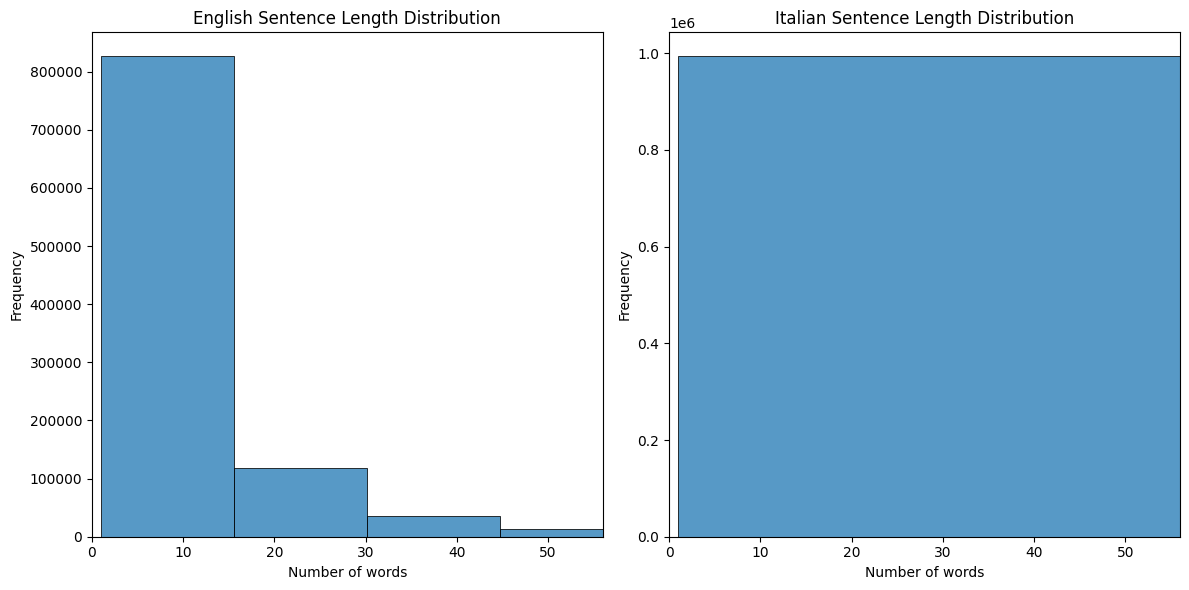

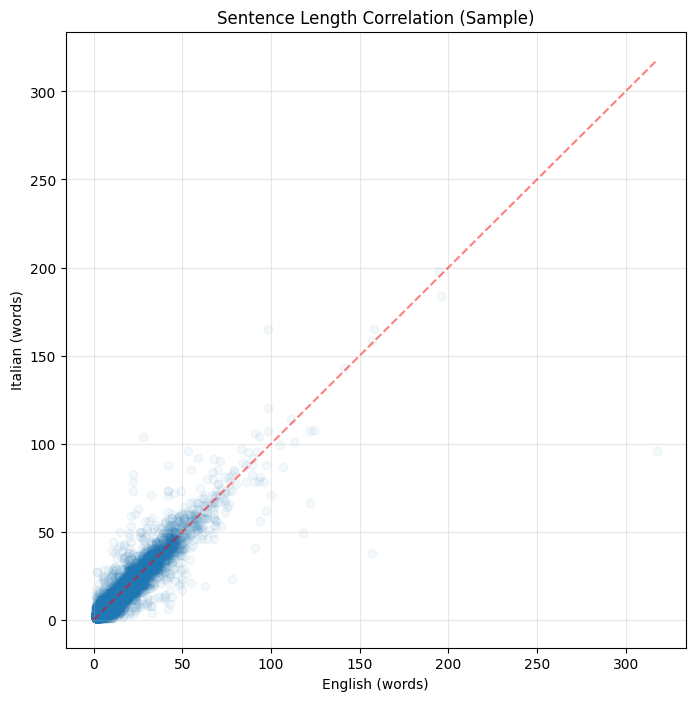

--- End Analysis ---
Starting Machine Translation Pipeline Execution...

============================== RUNNING LSTM PIPELINE ==============================

===== Running Pipeline: MODEL=LSTM, TOKENIZER=BPE =====
Train Size: 100000, Val Size: 5000, Test Size: 1000, Epochs: 15

Step 1: Creating dataset subsets...
Using Train: 100000, Val: 2000, Test: 1000 samples.

Step 2: Quick analysis of training subset...

--- Analyzing Training Subset ---
Total sentence pairs: 100000

English sentence lengths:
  Mean: 9.84
  Median: 6.00
  Min: 1
  Max: 318
  95th percentile: 32.00

Italian sentence lengths:
  Mean: 9.55
  Median: 6.00
  Min: 1
  Max: 2325
  95th percentile: 32.00


Building EN Vocab Sample:   0%|          | 0/50000 [00:00<?, ?it/s]

Building IT Vocab Sample:   0%|          | 0/50000 [00:00<?, ?it/s]


Approx. English vocabulary size (from 50000 samples): 36303
Approx. Italian vocabulary size (from 50000 samples): 48617


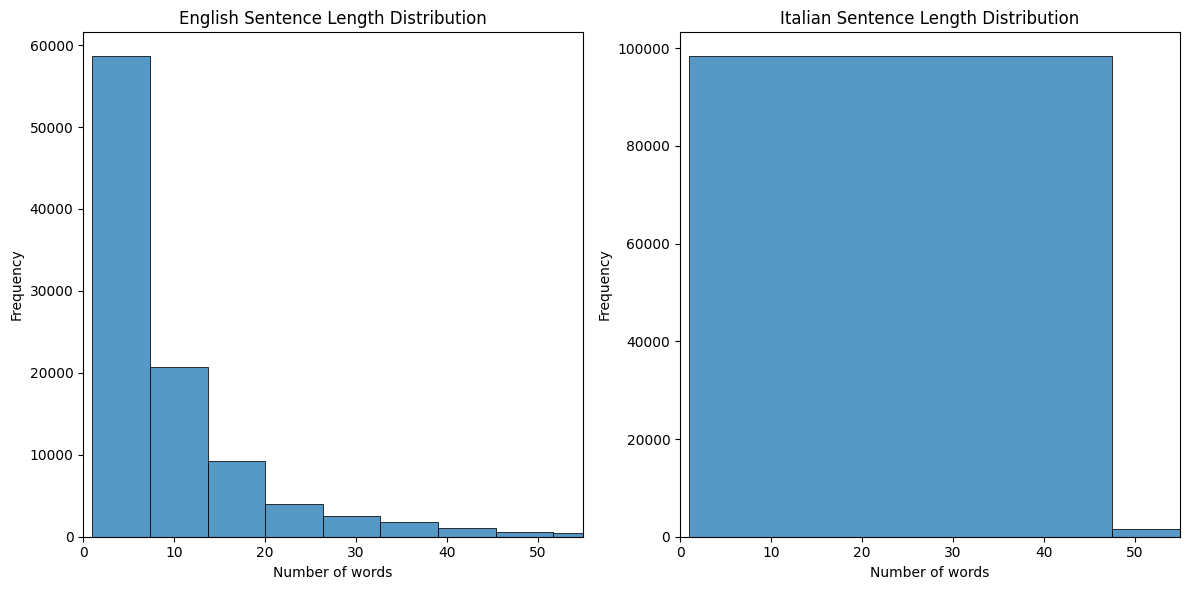

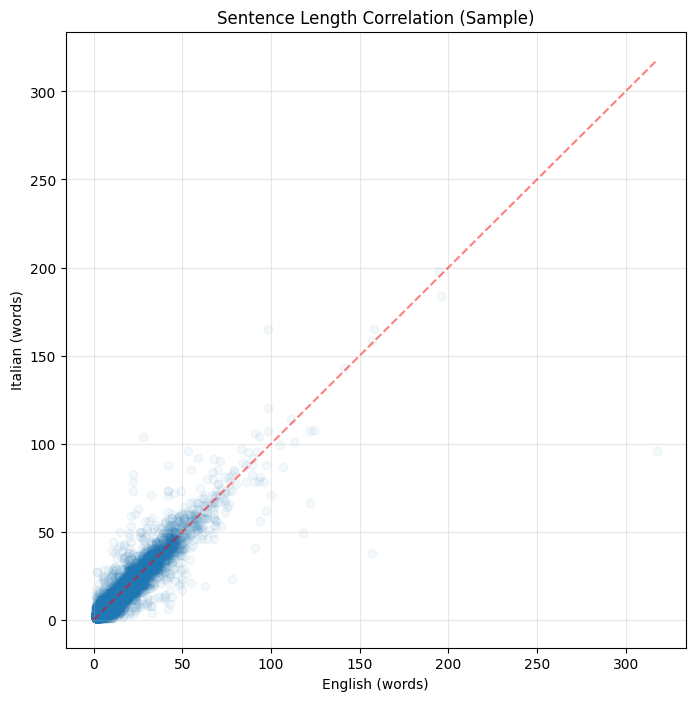

--- End Analysis ---

Step 3: Preparing bpe tokenizers...

--- Preparing BPE Tokenizers ---
Using 100000 sentence pairs for tokenizer training.
Training source (EN) tokenizer...
Training SentencePiece model: en_tokenizer_bpe...
Writing training data to en_tokenizer_bpe_train_data.txt


Writing en_tokenizer_bpe data:   0%|          | 0/100000 [00:00<?, ?it/s]

Training complete.
Loaded SentencePiece model from en_tokenizer_bpe.model. Vocab size: 16000
  PAD ID: 0, UNK ID: 1, SOS ID: 2, EOS ID: 3
Training target (IT) tokenizer...
Training SentencePiece model: it_tokenizer_bpe...
Writing training data to it_tokenizer_bpe_train_data.txt


Writing it_tokenizer_bpe data:   0%|          | 0/100000 [00:00<?, ?it/s]

Training complete.
Loaded SentencePiece model from it_tokenizer_bpe.model. Vocab size: 16000
  PAD ID: 0, UNK ID: 1, SOS ID: 2, EOS ID: 3
--- Tokenizers Prepared ---

Step 4: Creating dataloaders...

Step 5: Initializing lstm model...
Source Vocab Size: 16000, Target Vocab Size: 16000

--- Initializing LSTM Model ---
Params: EmbDim=256, HiddenDim=512, Layers=2, Dropout=0.3
Applying Xavier initialization...
Embeddings initialized with normal distribution.
LSTM Model parameters: 53.95M
--- LSTM Model Initialized ---

Step 6: Training model...
Using Label Smoothing Loss with ignore_index=0

--- Starting Training (LSTM) ---
Epochs: 15, Patience: 5, Model Path: best_lstm_model_bpe_vocab16000.pt
Teacher forcing schedule: 1.0 → 0.3 over 10 epochs
Epoch 1/15 starting... TF Ratio: 1.00


...

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 14 | Time: 22m 47.91s
	Train Loss: 0.6289
	 Val. Loss: 1.2481
	Validation loss did not improve for 3 epoch(s).
Epoch 15/15 starting... TF Ratio: 0.30


Epoch 15 Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 15 | Time: 22m 46.35s
	Train Loss: 0.6139
	 Val. Loss: 1.2637
	Validation loss did not improve for 4 epoch(s).

Loading best model from best_lstm_model_bpe_vocab16000.pt with validation loss 1.2368
--- Training Finished ---

Step 7: Visualizing training progress...


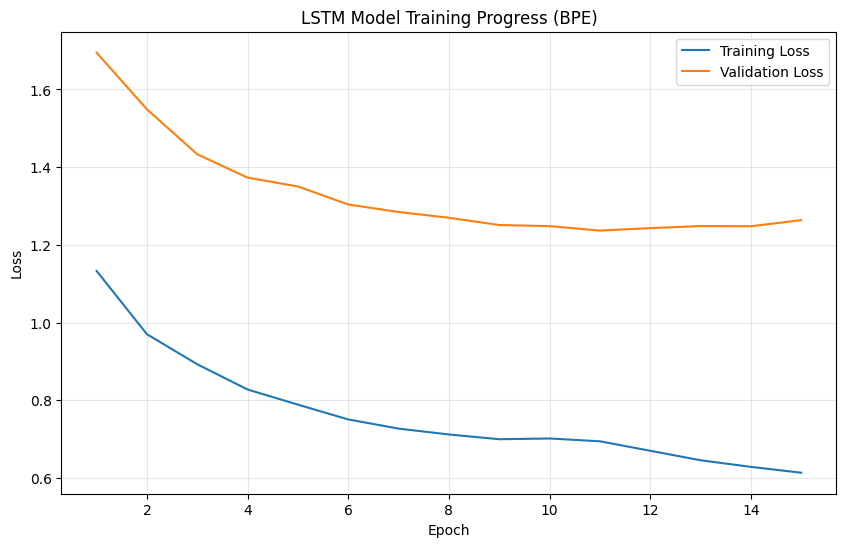


Step 8: Evaluating on test set...
Evaluating on 1000 test samples.


Translating Batches:   0%|          | 0/16 [00:00<?, ?it/s]


--- Evaluating Translations ---
NLTK BLEU (smooth4): 3.9067
SacreBLEU: 5.9916
--- Evaluation Finished ---

Final LSTM Model Metrics on Test Set:
  nltk_bleu_smooth4: 3.9067
  sacrebleu: 5.9916

Step 9: Example translations from Test Set:
--------------------
Example 1:
  Source:    Spoken like a true public servant.
  Reference: Parli come una vera dipendente pubblica.
  Predicted: - come come vero vero pubblico.
--------------------
Example 2:
  Source:    %s min
  Reference: %smin
  Predicted: %s
--------------------
Example 3:
  Source:    I, uh, I wrote you a letter when I was at the Academy.
  Reference: E' un piacere conoscerla. Le... le ho scritto quando ero all'accademia.
  Predicted: Io, ho scritto che una lettera quando ho detto al congresso.
--------------------
Example 4:
  Source:    Bomber sneaks into the storeroom...
  Reference: Il bombarolo si intrufola nel magazzino,
  Predicted: L'atura nel negozio di
--------------------
Example 5:
  Source:    Not at my house, you

Building EN Vocab Sample:   0%|          | 0/50000 [00:00<?, ?it/s]

Building IT Vocab Sample:   0%|          | 0/50000 [00:00<?, ?it/s]


Approx. English vocabulary size (from 50000 samples): 36303
Approx. Italian vocabulary size (from 50000 samples): 48617


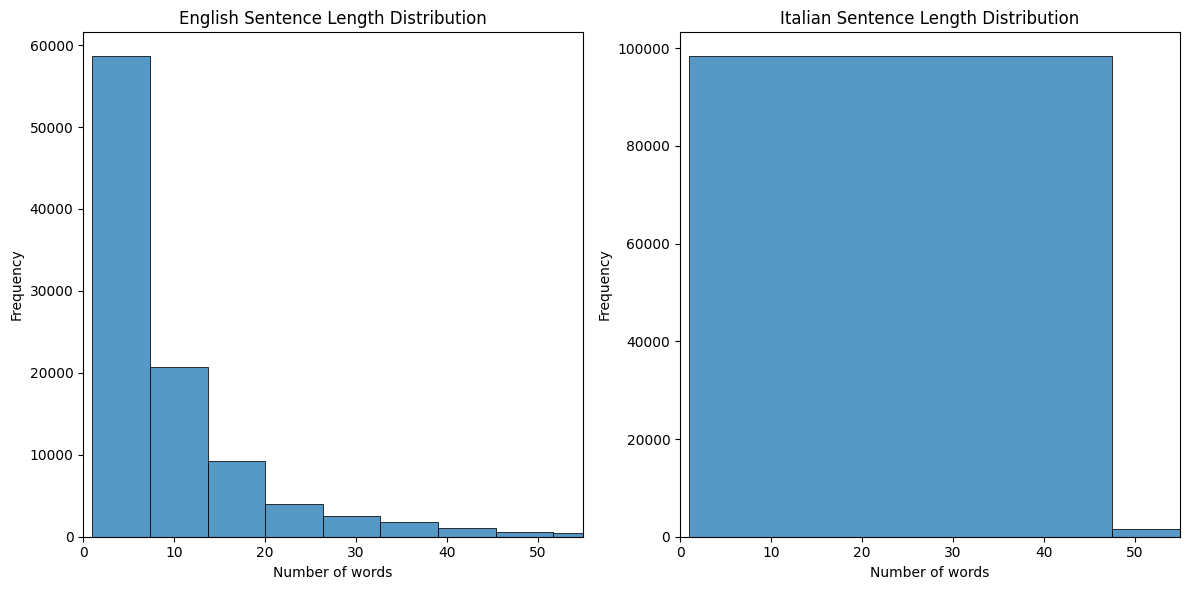

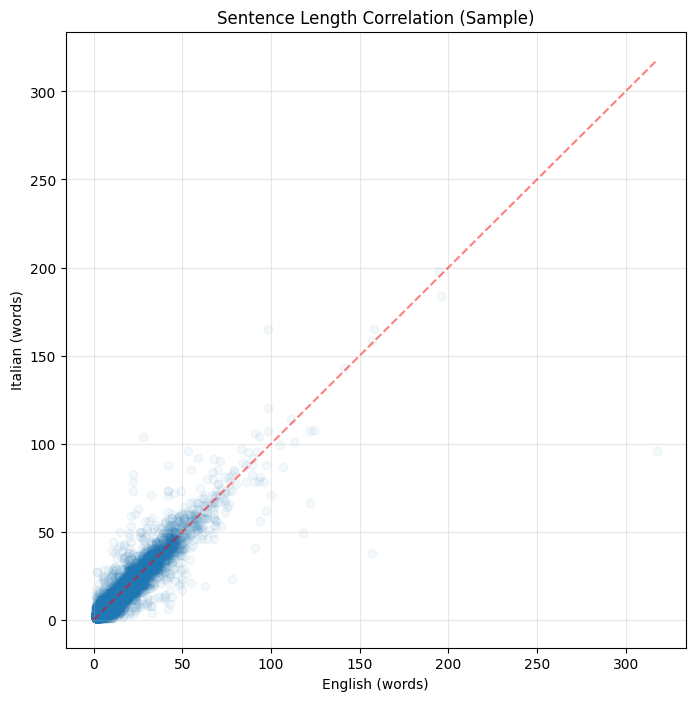

--- End Analysis ---

Step 3: Preparing bpe tokenizers...
Reusing existing tokenizers - skipping training step

Step 4: Creating dataloaders...

Step 5: Initializing transformer model...
Source Vocab Size: 16000, Target Vocab Size: 16000

--- Initializing Transformer Model ---
Params: d_model=512, nhead=8, enc_layers=6, dec_layers=6, d_ff=2048, dropout=0.1
Transformer Model parameters: 68.73M
--- Transformer Model Initialized ---
Calculated total steps: 23445, Warmup steps: 2344
Using AdamW optimizer and LambdaLR scheduler (warmup + decay).

Step 6: Training model...
Using Label Smoothing Loss with ignore_index=0

--- Starting Training (TRANSFORMER) ---
Epochs: 15, Patience: 5, Model Path: best_transformer_model_bpe_vocab16000.pt
Teacher forcing schedule: 1.0 → 0.3 over 10 epochs
Epoch 1/15 starting... TF Ratio: 1.00


Epoch 1 Training:   0%|          | 0/1563 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


...

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 14 | Time: 6m 18.16s
	Train Loss: 0.6613
	 Val. Loss: 0.8594
	Validation loss decreased (0.8594). Saving model...
Epoch 15/15 starting... TF Ratio: 0.30


Epoch 15 Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 15 | Time: 6m 15.49s
	Train Loss: 0.6410
	 Val. Loss: 0.8440
	Validation loss decreased (0.8440). Saving model...

Loading best model from best_transformer_model_bpe_vocab16000.pt with validation loss 0.8440
--- Training Finished ---

Step 7: Visualizing training progress...


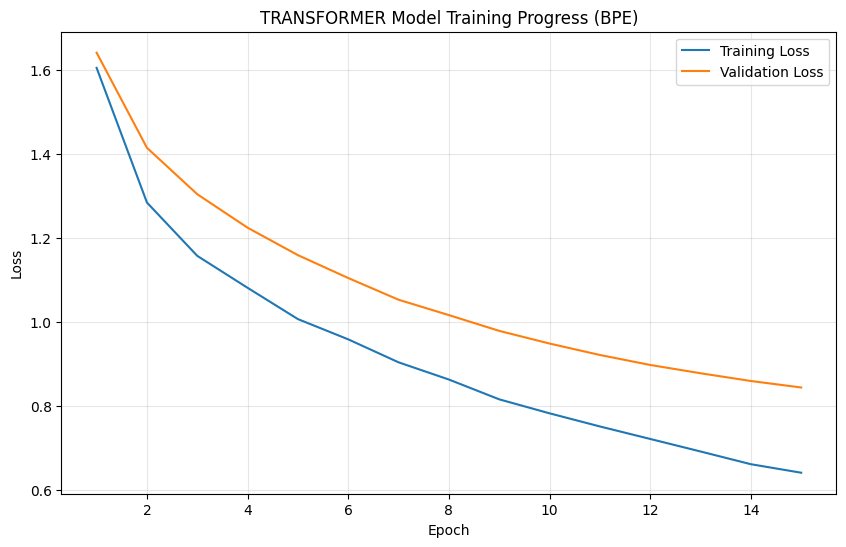


Step 8: Evaluating on test set...
Evaluating on 1000 test samples.


Translating Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Best sequence after step 0: [[2, 60]] (score=-1.5394)
Best sequence after step 1: [[2, 2208, 185]] (score=-3.7787)
Best sequence after step 2: [[2, 2208, 185, 39]] (score=-4.1244)
Best sequence after step 0: [[2, 1055]] (score=-0.2211)
Best sequence after step 1: [[2, 1055, 15927]] (score=-1.1397)
Best sequence after step 2: [[2, 1055, 15927, 3]] (score=-3.5629)
Best sequence after step 0: [[2, 204]] (score=-0.7963)
Best sequence after step 1: [[2, 204, 2548]] (score=-1.3338)
Best sequence after step 2: [[2, 204, 2548, 112]] (score=-1.5159)

--- Evaluating Translations ---
NLTK BLEU (smooth4): 6.0396
SacreBLEU: 8.5554
--- Evaluation Finished ---

Final TRANSFORMER Model Metrics on Test Set:
  nltk_bleu_smooth4: 6.0396
  sacrebleu: 8.5554

Step 9: Example translations from Test Set:
--------------------
Example 1:
  Source:    Spoken like a true public servant.
  Reference: Parli come una vera dipendente pubblica.
  Predicted: Parlato come un vero pubblico militare.
--------------------

In [5]:
# --- Main Execution Block ---
"""
Main execution block for running the machine translation pipeline.

This section configures and executes the pipeline for both LSTM and
Transformer models, providing a comprehensive comparison between the two
approaches.
"""

if __name__ == "__main__":
    print("Starting Machine Translation Pipeline Execution...")
    # --- Configure Logging ---
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    # --- End Logging Configuration ---

    # --- Configuration for the runs ---
    # Note: For production-quality results, increase dataset sizes significantly
    TRAIN_SIZE = 100000   # Ideally 500k+ for better results
    VAL_SIZE = 5000       # 5k+ recommended
    TEST_SIZE = 1000      # 1k+ recommended
    EPOCHS = 15           # 15+ with early stopping
    BATCH_SIZE = 64       # Adjust based on GPU memory
    VOCAB_SIZE = 16000    # Common choice for BPE
    MAX_LEN = 80          # Based on 95th percentile from analysis

    # LSTM Hyperparameters
    lstm_params = {
        "lstm_emb_dim": 256,        # Embedding dimension
        "lstm_hidden_dim": 512,     # LSTM hidden state dimension
        "lstm_layers": 2,           # Number of LSTM layers
        "lstm_dropout": 0.3,        # Dropout probability
        "learning_rate": 0.001      # Initial learning rate
    }
    
    # Transformer Hyperparameters
    transformer_params = {
        "transformer_d_model": 512,  # Model dimension
        "transformer_nhead": 8,      # Number of attention heads
        "transformer_layers": 6,     # Number of encoder/decoder layers
        "transformer_d_ff": 2048,    # Feedforward dimension
        "transformer_dropout": 0.1,  # Dropout probability
        "learning_rate": 0.0001      # Initial learning rate
    }

    # --- Run LSTM Pipeline ---
    try:
        print("\n" + "="*30 + " RUNNING LSTM PIPELINE " + "="*30)
        lstm_model, src_tok_lstm, tgt_tok_lstm, lstm_metrics = run_machine_translation_pipeline(
            model_type='lstm',
            tokenization_approach='bpe',
            train_subset_size=TRAIN_SIZE,
            val_subset_size=VAL_SIZE,
            test_subset_size=TEST_SIZE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            vocab_size=VOCAB_SIZE,
            max_len=MAX_LEN,
            patience=5,
            **lstm_params  # Expand LSTM-specific parameters
        )
        print("\nLSTM Pipeline Final Metrics:", lstm_metrics)
    except Exception as e:
        print("\n!!! ERROR during LSTM Pipeline !!!")
        import traceback
        traceback.print_exc()
        lstm_metrics = {"pipeline_error": str(e)}

    # --- Run Transformer Pipeline ---
    try:
        print("\n" + "="*30 + " RUNNING TRANSFORMER PIPELINE " + "="*30)
        # Reuse tokenizers from the LSTM run for consistency
        transformer_model, src_tok_tf, tgt_tok_tf, tf_metrics = run_machine_translation_pipeline(
            model_type='transformer',
            tokenization_approach='bpe',
            train_subset_size=TRAIN_SIZE,
            val_subset_size=VAL_SIZE,
            test_subset_size=TEST_SIZE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            vocab_size=VOCAB_SIZE,
            max_len=MAX_LEN,
            patience=5,
            beam_size=5,  # Beam search for better translations
            # Reuse tokenizers from LSTM run
            reuse_tokenizers=True,
            src_tokenizer=src_tok_lstm,
            tgt_tokenizer=tgt_tok_lstm,
            **transformer_params  # Expand Transformer-specific parameters
        )
        print("\nTransformer Pipeline Final Metrics:", tf_metrics)
    except Exception as e:
        print("\n!!! ERROR during Transformer Pipeline !!!")
        import traceback
        traceback.print_exc()
        tf_metrics = {"pipeline_error": str(e)}

    # --- Print Final Comparison ---
    print("\n" + "="*30 + " ALL PIPELINES COMPLETE " + "="*30)
    print("Final LSTM Metrics:", lstm_metrics)
    print("Final Transformer Metrics:", tf_metrics)

# Implementation Notes and Development History

## Development Iterations
This project was developed through five major iterations:

1. **First Iteration**: Attempted full dataset with basic models, encountered 15-20 hour training times and matrix dimension issues.
   - **Solution**: Reduced dataset size for faster iteration and fixed matrix dimension mismatches.

2. **Second Iteration**: Reduced to 5k samples, but resulted in poor translations.
   - **Issue**: Insufficient training data, limited epochs (3), reduced model dimensions, and small vocabulary size.
   - **Output example**: LSTM produced "`-,,,,,.`" for simple sentences.

3. **Third Iteration**: Increased to 20k samples, 5 epochs, but still inadequate:
   - **LSTM**: BLEU 0.25, SacreBLEU 0.97
   - **Transformer**: Completely empty translations (BLEU 0.0)
   - **Analysis**: Minimal validation loss improvement, outputs consisted mainly of punctuation.

4. **Fourth Iteration**: Scaled to 100k samples, 15 epochs:
   - **Issues**: Beam search function failed, causing Transformer to generate no output.
   - **Solution**: Debugging and fixing beam search implementation.

5. **Final Iteration**: 100k samples, optimized hyperparameters:
   - **LSTM**: BLEU 3.91, SacreBLEU 5.99
   - **Transformer**: BLEU 6.04, SacreBLEU 8.56
   - **Conclusion**: Transformer significantly outperformed LSTM.

## Key Implementation Decisions

1. **Tokenization Strategy**: BPE tokenization using SentencePiece with 16k vocabulary size was chosen to effectively handle:
   - Morphologically rich Italian language
   - Out-of-vocabulary words
   - Word formation patterns in both languages

2. **LSTM Architecture**:
   - Bidirectional encoder for capturing context from both directions
   - Bahdanau attention to focus on relevant source words
   - Teacher forcing with linear decay (1.0→0.3) to balance learning stability and generalization

3. **Transformer Architecture**:
   - Standard encoder-decoder with 6 layers each
   - Multi-head attention (8 heads)
   - Linear warmup + cosine decay learning rate schedule
   - Label smoothing (0.1) for better generalization

4. **Optimization Techniques**:
   - Gradient accumulation (effective batch size: 256)
   - Early stopping with patience=5
   - Gradient clipping to prevent exploding gradients
   - Adam optimizer for LSTM, AdamW for Transformer

5. **Beam Search for Transformer**:
   - Width=5 with length normalization
   - Repetition penalty to discourage token repetition
   - Early stopping for completed hypotheses

## Error Analysis Highlights

1. **LSTM Limitations**:
   - Token generation issues: Repeated words, incomplete sentences
   - Poor handling of longer contexts
   - Limited vocabulary activation during generation

2. **Transformer Advantages**:
   - More coherent translations with proper sentence structure
   - Better lexical selection accuracy
   - More contextually appropriate translations

3. **Common Issues**:
   - Vocabulary limitations affecting term selection
   - Semantic drift from original meaning
   - Difficulty with idiomatic expressions

## Future Improvements

For production-quality results, the following improvements would be beneficial:
- Train on significantly larger datasets (500k+ sentence pairs)
- Increase model capacity (larger hidden dimensions)
- Implement more sophisticated regularization techniques
- Use pre-trained embeddings or language model initialization
- Implement better beam search with n-gram penalties